# Functional evolution of the human OR repertoire along the ancestral tree

Reconstructs how odorant-recognition breadth was gained, partitioned and lost across
every edge of the human olfactory-receptor phylogeny, using the calibrated hybrid
activation threshold (p ≥ 0.83, experimental ground truth substituted where available).

**Analyses**
1. Hybrid tip matrix — predictions with M2OR override keyed on *exact amino-acid sequence identity*
2. Binarised ASR matrix + hysteresis flags for threshold-robust gain/loss calls
3. Gain / loss across all 431 internal edges and 433 tip edges
4. Neo- / sub-functionalisation / loss classification at every bifurcation
5. Seriated activation heatmap for the key nodes
6. Functional (Jaccard) vs phylogenetic (patristic) distance, Mantel-tested
7. Ancestor → tip: where each modern receptor's repertoire came from
8. Odor-tag enrichment of gained and lost ligand sets
9. Tree figures (matplotlib) + TreeProfiler-ready annotation export

**Interpretive frame.** OR repertoires evolve by birth-and-death (Nei & Rooney 2005
*Annu Rev Genet*; Niimura & Nei 2003 *PNAS*; Nei, Niimura & Nozawa 2008 *Nat Rev Genet*),
with repertoire size tracking ecology (Hughes et al. 2018 *MBE*; Policarpo et al. 2024
*Nat Commun*; Christmas et al. 2023 *Science*). What is *not* established is whether
gene-level turnover translates into ligand-level functional turnover. That is the gap
this notebook targets. Duplicate-fate vocabulary follows Ohno (1970) for
neofunctionalisation and Force et al. (1999) *Genetics* for the
duplication–degeneration–complementation (DDC) model of subfunctionalisation.

---
*This notebook is **self-contained**: the four helper modules (`core`, `chem`, `m2or_control`, `tagenrich`) are inlined and registered in the setup cell below, so no external `.py` files are required. Only the six input data files (tree, ASR/reference probability matrices, M2OR pairs, odor tags, FASTA) need to be present at the paths named in `core.load_all`.*

In [1]:
# ==========================================================================
# Self-contained setup: helper modules inlined (no external .py files needed)
# Sources are base64-embedded below and registered as importable modules,
# so every `core.`, `chem.`, `mc.`, `te.` call downstream works unchanged.
# ==========================================================================
import sys, types, base64, itertools, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import stats
warnings.filterwarnings("ignore")

_HELPER_SRC = {
    "core": "IiIiQ29yZSBhbmFseXNpcyBsb2dpYyBmb3IgT1IgZnVuY3Rpb25hbCBldm9sdXRpb24gYWNyb3NzIHRoZSBodW1hbiBPUiB0cmVlLiIiIgpmcm9tIF9fZnV0dXJlX18gaW1wb3J0IGFubm90YXRpb25zCmltcG9ydCBpdGVydG9vbHMsIGpzb24KZnJvbSBwYXRobGliIGltcG9ydCBQYXRoCmltcG9ydCBudW1weSBhcyBucCwgcGFuZGFzIGFzIHBkCmZyb20gc2NpcHkgaW1wb3J0IHN0YXRzCgpVUCA9IFBhdGgoIi9tbnQvdXNlci1kYXRhL3VwbG9hZHMiKQpUSFJFU0gsIExPVyA9IDAuODMsIDAuNzAKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSBsb2FkaW5nIC0tLQpkZWYgcmVhZF9mYXN0YShwKToKICAgIHNlcXMsIGggPSB7fSwgTm9uZQogICAgZm9yIGxpbmUgaW4gb3BlbihwKToKICAgICAgICBsaW5lID0gbGluZS5zdHJpcCgpCiAgICAgICAgaWYgbGluZS5zdGFydHN3aXRoKCI+Iik6CiAgICAgICAgICAgIGggPSBsaW5lWzE6XS5zcGxpdCgpWzBdOyBzZXFzW2hdID0gW10KICAgICAgICBlbGlmIGg6CiAgICAgICAgICAgIHNlcXNbaF0uYXBwZW5kKGxpbmUpCiAgICByZXR1cm4ge2s6ICIiLmpvaW4odikgZm9yIGssIHYgaW4gc2Vxcy5pdGVtcygpfQoKCmRlZiBsb2FkX2FsbChkcm9wX2ZsYWdnZWRfbXV0YW50cz1GYWxzZSk6CiAgICBhc3IgPSBwZC5yZWFkX2NzdihVUC8iYXNyX21lZGlhbl9wcm9iYWJpbGl0eV93aWRlLmNzdiIsIGluZGV4X2NvbD0wKQogICAgYXNyLmluZGV4ID0gW2kucmVwbGFjZSgiX0FTUiIsICIiKSBmb3IgaSBpbiBhc3IuaW5kZXhdCiAgICByZWYgPSBwZC5yZWFkX2NzdihVUC8icmVmZXJlbmNlX21lZGlhbl9wcm9iYWJpbGl0eV93aWRlLmNzdiIsIGluZGV4X2NvbD0wKQogICAgZmFzdGEgPSByZWFkX2Zhc3RhKFVQLyJQRjEzODUzXzk2MDZfNzk1NV83NzQwXzc3NjRfNzU3NDNfMTM3MjQ2LmZhIikKICAgIG0yb3IgPSBwZC5yZWFkX2NzdihVUC8ibTJvcl9wYWlyc19tb2RlbC5jc3YiLAogICAgICAgICAgICAgICAgICAgICAgIHVzZWNvbHM9WyJTcGVjaWVzIiwiVW5pUHJvdCBJRCIsIlNlcXVlbmNlIiwiU01JTEVTIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAic21pbGVzX2lkIiwiUmVzcG9uc2l2ZSIsIm11dGF0aW9uIl0pCiAgICBvZG9ycyA9IHBkLnJlYWRfY3N2KFVQLyJpbmNoaV9zbWlsZXNfb2RvcnMuY3N2IikKICAgIHJldHVybiBhc3IsIHJlZiwgZmFzdGEsIG0yb3IsIG9kb3JzCgoKZGVmIGJ1aWxkX2h5YnJpZF90aXBzKHJlZiwgZmFzdGEsIG0yb3IsIGRyb3BfZmxhZ2dlZF9tdXRhbnRzPUZhbHNlKToKICAgICIiIkh1bWFuIHRpcCBtYXRyaXg6IHByZWRpY3Rpb25zIGF0IFRIUkVTSCwgb3ZlcnJpZGRlbiBieSBNMk9SIGdyb3VuZCB0cnV0aC4KCiAgICBPdmVycmlkZSBpcyBrZXllZCBvbiBFWEFDVCBhbWluby1hY2lkIHNlcXVlbmNlIGlkZW50aXR5LCBuZXZlciBVbmlQcm90IElEOgogICAgbXV0YW50IHJlY2VwdG9ycyBzaGFyZSB0aGUgcGFyZW50IFVuaVByb3QgYWNjZXNzaW9uIGJ1dCBkaWZmZXIgaW4gc2VxdWVuY2UsCiAgICBzbyBzZXF1ZW5jZSBtYXRjaGluZyBleGNsdWRlcyB0aGVtIGF1dG9tYXRpY2FsbHkuCiAgICAiIiIKICAgIGh1bSA9IHtrOiB2IGZvciBrLCB2IGluIGZhc3RhLml0ZW1zKCkgaWYgay5zdGFydHN3aXRoKCI5NjA2LiIpfQogICAgc2VxMnBpZCA9IHt2OiBrIGZvciBrLCB2IGluIGh1bS5pdGVtcygpfQogICAgbWggPSBtMm9yW20yb3IuU3BlY2llcy5zdHIubG93ZXIoKS5zdHIuc3RyaXAoKSA9PSAiaG9tbyBzYXBpZW5zIl0uY29weSgpCiAgICBtaFsicGlkIl0gPSBtaC5TZXF1ZW5jZS5tYXAoc2VxMnBpZCkKICAgIG92ID0gbWguZHJvcG5hKHN1YnNldD1bInBpZCJdKS5jb3B5KCkKICAgIGlmIGRyb3BfZmxhZ2dlZF9tdXRhbnRzOgogICAgICAgIG92ID0gb3Zbfm92Lm11dGF0aW9uLmFzdHlwZShzdHIpLnN0ci5sb3dlcigpLmVxKCJ0cnVlIildCgogICAgcm93cyA9IFtpIGZvciBpIGluIHJlZi5pbmRleCBpZiBzdHIoaSkuc3RhcnRzd2l0aCgiOTYwNi4iKV0KICAgIFAgPSByZWYubG9jW3Jvd3NdCiAgICBiaW5hcnkgPSAoUCA+PSBUSFJFU0gpLmFzdHlwZShucC5pbnQ4KQoKICAgIHBhaXIgPSBvdi5ncm91cGJ5KFsicGlkIiwgInNtaWxlc19pZCJdKS5SZXNwb25zaXZlLm1heCgpCiAgICBzcmMgPSBwZC5EYXRhRnJhbWUoMCwgaW5kZXg9YmluYXJ5LmluZGV4LCBjb2x1bW5zPWJpbmFyeS5jb2x1bW5zLCBkdHlwZT1ucC5pbnQ4KQogICAgaWR4ID0gcGQuTXVsdGlJbmRleC5mcm9tX2ZyYW1lKHBhaXIucmVzZXRfaW5kZXgoKVtbInBpZCIsICJzbWlsZXNfaWQiXV0pCiAgICBmb3IgKHBpZCwgc2lkKSwgdmFsIGluIHBhaXIuaXRlbXMoKToKICAgICAgICBpZiBwaWQgaW4gYmluYXJ5LmluZGV4IGFuZCBzaWQgaW4gYmluYXJ5LmNvbHVtbnM6CiAgICAgICAgICAgIGJpbmFyeS5hdFtwaWQsIHNpZF0gPSBpbnQodmFsKQogICAgICAgICAgICBzcmMuYXRbcGlkLCBzaWRdID0gMQogICAgcmV0dXJuIGJpbmFyeSwgc3JjLCBQLCBsZW4ocGFpcikKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSB0cmVlIC0tLS0KY2xhc3MgVHJlZToKICAgICIiIk1pbmltYWwgcm9vdGVkLXRyZWUgd3JhcHBlcjogcGFyZW50cywgY2hpbGRyZW4sIGRlcHRocywgcGF0cmlzdGljIGRpc3RzLiIiIgogICAgZGVmIF9faW5pdF9fKHNlbGYsIHBhdGgpOgogICAgICAgIGltcG9ydCBkZW5kcm9weQogICAgICAgIHNlbGYudCA9IGRlbmRyb3B5LlRyZWUuZ2V0KHBhdGg9c3RyKHBhdGgpLCBzY2hlbWE9Im5ld2ljayIsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgcHJlc2VydmVfdW5kZXJzY29yZXM9VHJ1ZSwgcm9vdGluZz0iZm9yY2Utcm9vdGVkIikKICAgICAgICBzZWxmLm5vZGUgPSB7fQogICAgICAgIGZvciBuZCBpbiBzZWxmLnQucHJlb3JkZXJfbm9kZV9pdGVyKCk6CiAgICAgICAgICAgIG5hbWUgPSBuZC5sYWJlbCBpZiBuZC5sYWJlbCBlbHNlIChuZC50YXhvbi5sYWJlbCBpZiBuZC50YXhvbiBlbHNlIE5vbmUpCiAgICAgICAgICAgIGlmIG5hbWU6CiAgICAgICAgICAgICAgICBuYW1lID0gbmFtZS5yZXBsYWNlKCJOZXd8IiwgIiIpCiAgICAgICAgICAgICAgICBzZWxmLm5vZGVbbmFtZV0gPSBuZAogICAgICAgICAgICAgICAgbmQuX25hbWUgPSBuYW1lCiAgICAgICAgc2VsZi5wYXJlbnQsIHNlbGYuY2hpbGRyZW4sIHNlbGYuZGVwdGgsIHNlbGYuYmxlbiA9IHt9LCB7fSwge30sIHt9CiAgICAgICAgZm9yIG5hbWUsIG5kIGluIHNlbGYubm9kZS5pdGVtcygpOgogICAgICAgICAgICBwYXIgPSBuZC5wYXJlbnRfbm9kZQogICAgICAgICAgICBzZWxmLnBhcmVudFtuYW1lXSA9IGdldGF0dHIocGFyLCAiX25hbWUiLCBOb25lKSBpZiBwYXIgaXMgbm90IE5vbmUgZWxzZSBOb25lCiAgICAgICAgICAgIHNlbGYuY2hpbGRyZW5bbmFtZV0gPSBbZ2V0YXR0cihjLCAiX25hbWUiLCBOb25lKSBmb3IgYyBpbiBuZC5jaGlsZF9ub2RlcygpXQogICAgICAgICAgICBzZWxmLmJsZW5bbmFtZV0gPSBuZC5lZGdlX2xlbmd0aCBvciAwLjAKICAgICAgICBmb3IgbmQgaW4gc2VsZi50LnByZW9yZGVyX25vZGVfaXRlcigpOgogICAgICAgICAgICBuID0gZ2V0YXR0cihuZCwgIl9uYW1lIiwgTm9uZSkKICAgICAgICAgICAgaWYgbiBpcyBOb25lOiBjb250aW51ZQogICAgICAgICAgICBwID0gc2VsZi5wYXJlbnRbbl0KICAgICAgICAgICAgc2VsZi5kZXB0aFtuXSA9IChzZWxmLmRlcHRoW3BdICsgc2VsZi5ibGVuW25dKSBpZiBwIGVsc2UgMC4wCiAgICAgICAgc2VsZi5hbmMgPSB7fQogICAgICAgIGZvciBuIGluIHNlbGYubm9kZToKICAgICAgICAgICAgcGF0aCwgY3VyID0gW10sIG4KICAgICAgICAgICAgd2hpbGUgY3VyIGlzIG5vdCBOb25lOgogICAgICAgICAgICAgICAgcGF0aC5hcHBlbmQoY3VyKTsgY3VyID0gc2VsZi5wYXJlbnRbY3VyXQogICAgICAgICAgICBzZWxmLmFuY1tuXSA9IHBhdGgKCiAgICBkZWYgaXNfdGlwKHNlbGYsIG4pOiByZXR1cm4gbGVuKHNlbGYuY2hpbGRyZW5bbl0pID09IDAKICAgIGRlZiBuX2xlYXZlcyhzZWxmLCBuKTogcmV0dXJuIG1heCgxLCBsZW4oc2VsZi5ub2RlW25dLmxlYWZfbm9kZXMoKSkpCgogICAgZGVmIHBhdHJpc3RpYyhzZWxmLCBhLCBiKToKICAgICAgICBzYiA9IHNldChzZWxmLmFuY1tiXSkKICAgICAgICBtcmNhID0gbmV4dCh4IGZvciB4IGluIHNlbGYuYW5jW2FdIGlmIHggaW4gc2IpCiAgICAgICAgcmV0dXJuIHNlbGYuZGVwdGhbYV0gKyBzZWxmLmRlcHRoW2JdIC0gMiAqIHNlbGYuZGVwdGhbbXJjYV0KCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gZ2FpbiAvIGxvc3MgYWxvbmcgZWRnZXMgLS0tCmRlZiBlZGdlX3RhYmxlKHByb2IsIGJpbmFyeSwgdHJlZSwgbG93PUxPVyk6CiAgICAiIiJPbmUgcm93IHBlciBub2RlIHRoYXQgaGFzIGJvdGggaXRzZWxmIGFuZCBpdHMgcGFyZW50IHNjb3JlZC4iIiIKICAgIG91dCA9IFtdCiAgICBmb3IgbiBpbiBiaW5hcnkuaW5kZXg6CiAgICAgICAgcCA9IHRyZWUucGFyZW50LmdldChuKQogICAgICAgIGlmIHAgaXMgTm9uZSBvciBwIG5vdCBpbiBiaW5hcnkuaW5kZXg6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgY19iLCBwX2IgPSBiaW5hcnkubG9jW25dLnZhbHVlcy5hc3R5cGUoYm9vbCksIGJpbmFyeS5sb2NbcF0udmFsdWVzLmFzdHlwZShib29sKQogICAgICAgIGNfcCA9IHByb2IubG9jW25dLnZhbHVlcyBpZiBuIGluIHByb2IuaW5kZXggZWxzZSBOb25lCiAgICAgICAgcF9wID0gcHJvYi5sb2NbcF0udmFsdWVzIGlmIHAgaW4gcHJvYi5pbmRleCBlbHNlIE5vbmUKICAgICAgICBnYWluLCBsb3NzID0gKH5wX2IpICYgY19iLCBwX2IgJiAofmNfYikKICAgICAgICBpZiBjX3AgaXMgbm90IE5vbmUgYW5kIHBfcCBpcyBub3QgTm9uZToKICAgICAgICAgICAgZ19zdHIsIGxfc3RyID0gZ2FpbiAmIChwX3AgPD0gbG93KSwgbG9zcyAmIChjX3AgPD0gbG93KQogICAgICAgIGVsc2U6ICAjIHRpcCB3aXRoIGV4cGVyaW1lbnRhbCBvdmVycmlkZTogbm8gcHJvYmFiaWxpdHkgdG8gaHlzdGVyZXNpcyBvbgogICAgICAgICAgICBnX3N0ciwgbF9zdHIgPSBnYWluLCBsb3NzCiAgICAgICAgb3V0LmFwcGVuZChkaWN0KG5vZGU9biwgcGFyZW50PXAsIGJsZW49dHJlZS5ibGVuW25dLAogICAgICAgICAgICAgICAgICAgICAgICBpc190aXA9dHJlZS5pc190aXAobiksIG5fbGVhdmVzPXRyZWUubl9sZWF2ZXMobiksCiAgICAgICAgICAgICAgICAgICAgICAgIG5fcGFyZW50PWludChwX2Iuc3VtKCkpLCBuX2NoaWxkPWludChjX2Iuc3VtKCkpLAogICAgICAgICAgICAgICAgICAgICAgICBnYWluPWludChnYWluLnN1bSgpKSwgbG9zcz1pbnQobG9zcy5zdW0oKSksCiAgICAgICAgICAgICAgICAgICAgICAgIGdhaW5fc3RyaWN0PWludChnX3N0ci5zdW0oKSksIGxvc3Nfc3RyaWN0PWludChsX3N0ci5zdW0oKSksCiAgICAgICAgICAgICAgICAgICAgICAgIHJldGFpbmVkPWludCgocF9iICYgY19iKS5zdW0oKSkpKQogICAgZGYgPSBwZC5EYXRhRnJhbWUob3V0KQogICAgZGZbInR1cm5vdmVyIl0gPSBkZi5nYWluX3N0cmljdCArIGRmLmxvc3Nfc3RyaWN0CiAgICBkZlsibmV0Il0gPSBkZi5uX2NoaWxkIC0gZGYubl9wYXJlbnQKICAgIHUgPSBkZi5uX3BhcmVudCArIGRmLm5fY2hpbGQgLSBkZi5yZXRhaW5lZAogICAgZGZbImphY2NhcmRfcGMiXSA9IGRmLnJldGFpbmVkIC8gdS5yZXBsYWNlKDAsIG5wLm5hbikKICAgIGRmWyJmcmFjX3JvYnVzdCJdID0gKChkZi5nYWluX3N0cmljdCArIGRmLmxvc3Nfc3RyaWN0KSAvCiAgICAgICAgICAgICAgICAgICAgICAgICAoZGYuZ2FpbiArIGRmLmxvc3MpLnJlcGxhY2UoMCwgbnAubmFuKSkKICAgIHJldHVybiBkZgoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIG5lbyAvIHN1YiAvIGxvc3MgYXQgYmlmdXJjYXRpbmcgbm9kZXMgLS0tLS0KZGVmIGZhdGVfdGFibGUoYmluYXJ5LCB0cmVlKToKICAgICIiIkNsYXNzaWZ5IGVhY2ggaW50ZXJuYWwgbm9kZSdzIHNwbGl0IGJ5IHRoZSBmYXRlIG9mIHRoZSBwYXJlbnRhbCByZXBlcnRvaXJlLiIiIgogICAgcm93cyA9IFtdCiAgICBmb3IgcCBpbiBiaW5hcnkuaW5kZXg6CiAgICAgICAga2lkcyA9IFtjIGZvciBjIGluIHRyZWUuY2hpbGRyZW4uZ2V0KHAsIFtdKSBpZiBjIGluIGJpbmFyeS5pbmRleF0KICAgICAgICBpZiBsZW4oa2lkcykgIT0gMjoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBBLCBCID0ga2lkcwogICAgICAgIFAgPSBiaW5hcnkubG9jW3BdLnZhbHVlcy5hc3R5cGUoYm9vbCkKICAgICAgICBhID0gYmluYXJ5LmxvY1tBXS52YWx1ZXMuYXN0eXBlKGJvb2wpCiAgICAgICAgYiA9IGJpbmFyeS5sb2NbQl0udmFsdWVzLmFzdHlwZShib29sKQogICAgICAgIG5QID0gUC5zdW0oKQogICAgICAgIGlmIG5QID09IDA6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAga2VwdF9hbnkgPSBQICYgKGEgfCBiKQogICAgICAgIGtlcHRfb25lID0gUCAmIChhIF4gYikgICAgICAgICAgICAgICAgICMgY29tcGxlbWVudGFyeSByZXRlbnRpb24gLT4gRERDCiAgICAgICAga2VwdF9ib3RoID0gUCAmIGEgJiBiCiAgICAgICAgbG9zdF9ib3RoID0gUCAmIH4oYSB8IGIpCiAgICAgICAgbm92ZWxfQSA9IGEgJiB+UCAmIH5iICAgICAgICAgICAgICAgICAgIyBwcml2YXRlIG5vdmVsdHkKICAgICAgICBub3ZlbF9CID0gYiAmIH5QICYgfmEKICAgICAgICBub3ZlbF9zaGFyZWQgPSAoYSAmIGIpICYgflAKICAgICAgICB1bmlvbiA9IChQIHwgYSB8IGIpLnN1bSgpCiAgICAgICAgcm93cy5hcHBlbmQoZGljdCgKICAgICAgICAgICAgbm9kZT1wLCBjaGlsZF9BPUEsIGNoaWxkX0I9Qiwgbl9wYXJlbnQ9aW50KG5QKSwKICAgICAgICAgICAgbl9BPWludChhLnN1bSgpKSwgbl9CPWludChiLnN1bSgpKSwKICAgICAgICAgICAga2VwdF9ib3RoPWludChrZXB0X2JvdGguc3VtKCkpLCBrZXB0X29uZT1pbnQoa2VwdF9vbmUuc3VtKCkpLAogICAgICAgICAgICBsb3N0X2JvdGg9aW50KGxvc3RfYm90aC5zdW0oKSksCiAgICAgICAgICAgIG5vdmVsX0E9aW50KG5vdmVsX0Euc3VtKCkpLCBub3ZlbF9CPWludChub3ZlbF9CLnN1bSgpKSwKICAgICAgICAgICAgbm92ZWxfc2hhcmVkPWludChub3ZlbF9zaGFyZWQuc3VtKCkpLAogICAgICAgICAgICAjIGluZGljZXMKICAgICAgICAgICAgbG9zc19pbmRleD1sb3N0X2JvdGguc3VtKCkgLyBuUCwKICAgICAgICAgICAgc3ViX2luZGV4PShrZXB0X29uZS5zdW0oKSAvIGtlcHRfYW55LnN1bSgpKSBpZiBrZXB0X2FueS5zdW0oKSBlbHNlIG5wLm5hbiwKICAgICAgICAgICAgbmVvX2luZGV4PShub3ZlbF9BLnN1bSgpICsgbm92ZWxfQi5zdW0oKSkgLyB1bmlvbiBpZiB1bmlvbiBlbHNlIG5wLm5hbiwKICAgICAgICAgICAgYXN5bT1hYnMobm92ZWxfQS5zdW0oKSAtIG5vdmVsX0Iuc3VtKCkpIC8KICAgICAgICAgICAgICAgICBtYXgoMSwgbm92ZWxfQS5zdW0oKSArIG5vdmVsX0Iuc3VtKCkpLAogICAgICAgICkpCiAgICBkZiA9IHBkLkRhdGFGcmFtZShyb3dzKQogICAgIyBkb21pbmFudCByZWdpbWU6IHdoaWNoZXZlciBpbmRleCBpcyBsYXJnZXN0IGFmdGVyIHNjYWxpbmcgdG8gWzAsMV0KICAgIGlkeCA9IGRmW1sibG9zc19pbmRleCIsICJzdWJfaW5kZXgiLCAibmVvX2luZGV4Il1dLmZpbGxuYSgwKQogICAgZGZbInJlZ2ltZSJdID0gaWR4LmlkeG1heChheGlzPTEpLnN0ci5yZXBsYWNlKCJfaW5kZXgiLCAiIiwgcmVnZXg9RmFsc2UpCiAgICBkZi5sb2NbaWR4Lm1heChheGlzPTEpIDwgMC4xNSwgInJlZ2ltZSJdID0gInN0YXRpYyIKICAgIHJldHVybiBkZgoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSBzZXJpYXRpb24gLS0tLQpkZWYgc2VyaWF0ZV9jb2x1bW5zKHN1YjogcGQuRGF0YUZyYW1lKSAtPiBsaXN0OgogICAgIiIiT3JkZXIgbGlnYW5kcyBzbyBuZXN0ZWQgcmVwZXJ0b2lyZXMgZm9ybSBhIHN0YWlyY2FzZS4KCiAgICBTb3J0IGJ5ICh0b3RhbCBhY3RpdmF0aW9uIGRlc2MsIHRoZW4gdGhlIGJpbmFyeSBwYXR0ZXJuIHJlYWQgdG9wLXRvLWJvdHRvbQogICAgYXMgYSBudW1iZXIpLiBQcm9kdWNlcyBhIGJsb2NrLXRyaWFuZ3VsYXIgbGF5b3V0IHdpdGhvdXQgY2x1c3RlcmluZy4KICAgICIiIgogICAgViA9IHN1Yi52YWx1ZXMuYXN0eXBlKGludCkKICAgIHRvdCA9IFYuc3VtKGF4aXM9MCkKICAgIGtleSA9IFt0dXBsZShWWzosIGpdKSBmb3IgaiBpbiByYW5nZShWLnNoYXBlWzFdKV0KICAgIG9yZGVyID0gc29ydGVkKHJhbmdlKFYuc2hhcGVbMV0pLCBrZXk9bGFtYmRhIGo6ICgtdG90W2pdLCBrZXlbal0pLCByZXZlcnNlPUZhbHNlKQogICAgcmV0dXJuIFtzdWIuY29sdW1uc1tqXSBmb3IgaiBpbiBvcmRlcl0KCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSBtYW50ZWwgdGVzdCAtLS0KZGVmIG1hbnRlbChEMSwgRDIsIG5fcGVybT05OTk5LCBzZWVkPTApOgogICAgcm5nID0gbnAucmFuZG9tLmRlZmF1bHRfcm5nKHNlZWQpCiAgICBuID0gRDEuc2hhcGVbMF0KICAgIGl1ID0gbnAudHJpdV9pbmRpY2VzKG4sIDEpCiAgICB4LCB5ID0gRDFbaXVdLCBEMltpdV0KICAgIHJfb2JzID0gc3RhdHMuc3BlYXJtYW5yKHgsIHkpLnN0YXRpc3RpYwogICAgY250ID0gMAogICAgZm9yIF8gaW4gcmFuZ2Uobl9wZXJtKToKICAgICAgICBwID0gcm5nLnBlcm11dGF0aW9uKG4pCiAgICAgICAgciA9IHN0YXRzLnNwZWFybWFucihEMVtucC5peF8ocCwgcCldW2l1XSwgeSkuc3RhdGlzdGljCiAgICAgICAgaWYgYWJzKHIpID49IGFicyhyX29icyk6CiAgICAgICAgICAgIGNudCArPSAxCiAgICByZXR1cm4gcl9vYnMsIChjbnQgKyAxKSAvIChuX3Blcm0gKyAxKQoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLSBvZG9yLXRhZyBoZWxwZXJzIC0tLQpkZWYgdGFnX21hcChvZG9ycywgbTJvcik6CiAgICBzbSA9IG0yb3JbWyJTTUlMRVMiLCAic21pbGVzX2lkIl1dLmRyb3BfZHVwbGljYXRlcygpCiAgICBvID0gb2RvcnMubWVyZ2Uoc20sIG9uPSJTTUlMRVMiLCBob3c9ImlubmVyIikKICAgIGQgPSB7fQogICAgZm9yIHNpZCwgdGFncyBpbiB6aXAoby5zbWlsZXNfaWQsIG8uT2RvcnMuZmlsbG5hKCIiKSk6CiAgICAgICAgZFtzaWRdID0ge3Quc3RyaXAoKS5sb3dlcigpIGZvciB0IGluIHN0cih0YWdzKS5zcGxpdCgiLCIpIGlmIHQuc3RyaXAoKX0KICAgIHJldHVybiBkCgoKZGVmIHRhZ19lbnJpY2htZW50KHRhcmdldCwgYmFja2dyb3VuZCwgdGFncywgbl9wZXJtPTk5OTk5LCBzZWVkPTAsIG1pbl9vYnM9Myk6CiAgICAiIiJSaWdodC10YWlsZWQgcGVybXV0YXRpb24gZW5yaWNobWVudCBvZiBvZG9yIHRhZ3MgaW4gYSBsaWdhbmQgc3Vic2V0LiIiIgogICAgdGFyZ2V0LCBiYWNrZ3JvdW5kID0gbGlzdCh0YXJnZXQpLCBsaXN0KGJhY2tncm91bmQpCiAgICBrID0gbGVuKHRhcmdldCkKICAgIGlmIGsgPT0gMDoKICAgICAgICByZXR1cm4gcGQuRGF0YUZyYW1lKCkKICAgIGFsbF90YWdzID0gc29ydGVkKHt0IGZvciBzIGluIGJhY2tncm91bmQgZm9yIHQgaW4gdGFncy5nZXQocywgc2V0KCkpfSkKICAgIHRpID0ge3Q6IGkgZm9yIGksIHQgaW4gZW51bWVyYXRlKGFsbF90YWdzKX0KICAgIE0gPSBucC56ZXJvcygobGVuKGJhY2tncm91bmQpLCBsZW4oYWxsX3RhZ3MpKSwgZHR5cGU9bnAuaW50OCkKICAgIGZvciBpLCBzIGluIGVudW1lcmF0ZShiYWNrZ3JvdW5kKToKICAgICAgICBmb3IgdCBpbiB0YWdzLmdldChzLCBzZXQoKSk6CiAgICAgICAgICAgIE1baSwgdGlbdF1dID0gMQogICAgcG9zID0ge3M6IGkgZm9yIGksIHMgaW4gZW51bWVyYXRlKGJhY2tncm91bmQpfQogICAgb2JzID0gTVtbcG9zW3NdIGZvciBzIGluIHRhcmdldCBpZiBzIGluIHBvc11dLnN1bShheGlzPTApCiAgICBybmcgPSBucC5yYW5kb20uZGVmYXVsdF9ybmcoc2VlZCkKICAgIGdlID0gbnAuemVyb3MobGVuKGFsbF90YWdzKSkKICAgIE4gPSBNLnNoYXBlWzBdCiAgICBmb3IgXyBpbiByYW5nZShuX3Blcm0pOgogICAgICAgIHNlbCA9IHJuZy5jaG9pY2UoTiwgc2l6ZT1taW4oaywgTiksIHJlcGxhY2U9RmFsc2UpCiAgICAgICAgZ2UgKz0gKE1bc2VsXS5zdW0oYXhpcz0wKSA+PSBvYnMpCiAgICBleHAgPSBNLnN1bShheGlzPTApICogayAvIE4KICAgIGRmID0gcGQuRGF0YUZyYW1lKGRpY3QodGFnPWFsbF90YWdzLCBvYnM9b2JzLCB0b3RhbD1NLnN1bShheGlzPTApLCBleHA9ZXhwLAogICAgICAgICAgICAgICAgICAgICAgICAgICBwPShnZSArIDEpIC8gKG5fcGVybSArIDEpKSkKICAgIGRmWyJvYnNfZXhwIl0gPSBkZi5vYnMgLyBkZi5leHAucmVwbGFjZSgwLCBucC5uYW4pCiAgICByZXR1cm4gZGZbKGRmLm9icyA+PSBtaW5fb2JzKSAmIChkZi5vYnNfZXhwID4gMSldLnNvcnRfdmFsdWVzKCJwIikK",
    "chem": "IiIiQ2hlbWljYWwgY2hhcmFjdGVyaXNhdGlvbiBvZiBnYWluZWQgLyBsb3N0IGxpZ2FuZCBzZXRzIG9uIHRyZWUgZWRnZXMuIiIiCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKaW1wb3J0IG51bXB5IGFzIG5wLCBwYW5kYXMgYXMgcGQKZnJvbSBzY2lweSBpbXBvcnQgc3RhdHMKCiMgU01BUlRTIGNob3NlbiB0byBiZSBtdXR1YWxseSBpbnRlcnByZXRhYmxlIHJhdGhlciB0aGFuIG11dHVhbGx5IGV4Y2x1c2l2ZS4KU01BUlRTID0gewogICAgImNhcmJveHlsaWNfYWNpZCI6ICJbQ1gzXSg9TylbT1gySDFdIiwKICAgICJlc3RlciI6ICAgICAgICAgICAiW0NYM10oPVtPWDFdKVtPWDJIMF1bIzZdIiwKICAgICJsYWN0b25lIjogICAgICAgICAiWyM2O1JdW0NYMztSXSg9W09YMV0pW09YMkgwO1JdIiwKICAgICJhbGRlaHlkZSI6ICAgICAgICAiW0NYM0gxXSg9TylbIzZdIiwKICAgICJrZXRvbmUiOiAgICAgICAgICAiWyM2XVtDWDNdKD1PKVsjNl0iLAogICAgImFsY29ob2wiOiAgICAgICAgICJbT1gySF1bQ1g0XSIsCiAgICAicGhlbm9sIjogICAgICAgICAgIltPWDJIXWMiLAogICAgImV0aGVyIjogICAgICAgICAgICJbT0QyXShbIzZdKVsjNl0iLAogICAgInRoaW9sIjogICAgICAgICAgICJbU1gySF0iLAogICAgInN1bGZpZGUiOiAgICAgICAgICJbIzE2WDJIMF1bIzZdIiwKICAgICJhbWluZSI6ICAgICAgICAgICAiW05YMztIMixIMSxIMDshJChOPU8pOyEkKE4tQz1PKTshJChOLVM9TyldIiwKICAgICJuaXRyaWxlIjogICAgICAgICAiW05YMV0jW0NYMl0iLAogICAgImFyb21hdGljX3JpbmciOiAgICJjMWNjY2NjMSIsCiAgICAiaGV0ZXJvYXJvbWF0aWMiOiAgIlthOyFjXSIsCiAgICAiZnVyYW4iOiAgICAgICAgICAgImMxY2NvYzEiLAogICAgInB5cmF6aW5lIjogICAgICAgICJjMWNuY2NuMSIsCiAgICAidGVycGVub2lkX2xpa2UiOiAgIltDWDRdKFtDSDNdKShbQ0gzXSlbIzZdIiwgICAjIGdlbS1kaW1ldGh5bCwgaXNvcHJlbm9pZCBwcm94eQogICAgImFsa2VuZSI6ICAgICAgICAgICJbQ1gzXT1bQ1gzXSIsCiAgICAiaGFsb2dlbiI6ICAgICAgICAgIltGLENsLEJyLEldIiwKfQoKREVTQ1JJUFRPUlMgPSBbIk1XIiwgImNMb2dQIiwgIlRQU0EiLCAibkhlYXZ5IiwgIm5Sb3QiLCAibkFyUmluZyIsCiAgICAgICAgICAgICAgICJuQWxpUmluZyIsICJGcmFjQ1NQMyIsICJIQkQiLCAiSEJBIiwgIm5PIiwgIm5TIiwgIm5OIl0KCgpkZWYgZmVhdHVyaXNlKHNtaWxlc19ieV9pZDogZGljdCkgLT4gcGQuRGF0YUZyYW1lOgogICAgZnJvbSByZGtpdCBpbXBvcnQgQ2hlbSwgUkRMb2dnZXIKICAgIGZyb20gcmRraXQuQ2hlbSBpbXBvcnQgRGVzY3JpcHRvcnMsIENyaXBwZW4sIHJkTW9sRGVzY3JpcHRvcnMKICAgIFJETG9nZ2VyLkRpc2FibGVMb2coInJkQXBwLioiKQoKICAgIHBhdHQgPSB7azogQ2hlbS5Nb2xGcm9tU21hcnRzKHYpIGZvciBrLCB2IGluIFNNQVJUUy5pdGVtcygpfQogICAgcm93cyA9IFtdCiAgICBmb3Igc2lkLCBzbWkgaW4gc21pbGVzX2J5X2lkLml0ZW1zKCk6CiAgICAgICAgbSA9IENoZW0uTW9sRnJvbVNtaWxlcyhzbWkpIGlmIGlzaW5zdGFuY2Uoc21pLCBzdHIpIGVsc2UgTm9uZQogICAgICAgIGlmIG0gaXMgTm9uZToKICAgICAgICAgICAgY29udGludWUKICAgICAgICByID0gZGljdChzbWlsZXNfaWQ9c2lkLCBTTUlMRVM9c21pLAogICAgICAgICAgICAgICAgIE1XPURlc2NyaXB0b3JzLk1vbFd0KG0pLCBjTG9nUD1DcmlwcGVuLk1vbExvZ1AobSksCiAgICAgICAgICAgICAgICAgVFBTQT1EZXNjcmlwdG9ycy5UUFNBKG0pLCBuSGVhdnk9bS5HZXROdW1IZWF2eUF0b21zKCksCiAgICAgICAgICAgICAgICAgblJvdD1EZXNjcmlwdG9ycy5OdW1Sb3RhdGFibGVCb25kcyhtKSwKICAgICAgICAgICAgICAgICBuQXJSaW5nPXJkTW9sRGVzY3JpcHRvcnMuQ2FsY051bUFyb21hdGljUmluZ3MobSksCiAgICAgICAgICAgICAgICAgbkFsaVJpbmc9cmRNb2xEZXNjcmlwdG9ycy5DYWxjTnVtQWxpcGhhdGljUmluZ3MobSksCiAgICAgICAgICAgICAgICAgRnJhY0NTUDM9cmRNb2xEZXNjcmlwdG9ycy5DYWxjRnJhY3Rpb25DU1AzKG0pLAogICAgICAgICAgICAgICAgIEhCRD1yZE1vbERlc2NyaXB0b3JzLkNhbGNOdW1IQkQobSksCiAgICAgICAgICAgICAgICAgSEJBPXJkTW9sRGVzY3JpcHRvcnMuQ2FsY051bUhCQShtKSwKICAgICAgICAgICAgICAgICBuTz1zdW0oYS5HZXRTeW1ib2woKSA9PSAiTyIgZm9yIGEgaW4gbS5HZXRBdG9tcygpKSwKICAgICAgICAgICAgICAgICBuUz1zdW0oYS5HZXRTeW1ib2woKSA9PSAiUyIgZm9yIGEgaW4gbS5HZXRBdG9tcygpKSwKICAgICAgICAgICAgICAgICBuTj1zdW0oYS5HZXRTeW1ib2woKSA9PSAiTiIgZm9yIGEgaW4gbS5HZXRBdG9tcygpKSkKICAgICAgICBmb3IgaywgcCBpbiBwYXR0Lml0ZW1zKCk6CiAgICAgICAgICAgIHJba10gPSBpbnQobS5IYXNTdWJzdHJ1Y3RNYXRjaChwKSkgaWYgcCBpcyBub3QgTm9uZSBlbHNlIDAKICAgICAgICByb3dzLmFwcGVuZChyKQogICAgcmV0dXJuIHBkLkRhdGFGcmFtZShyb3dzKS5zZXRfaW5kZXgoInNtaWxlc19pZCIpCgoKZGVmIF9iaChwKToKICAgIHAgPSBucC5hc2FycmF5KHAsIGZsb2F0KTsgbiA9IGxlbihwKQogICAgaWYgbiA9PSAwOiByZXR1cm4gcAogICAgbyA9IG5wLmFyZ3NvcnQocCkKICAgIHEgPSBucC5taW5pbXVtLmFjY3VtdWxhdGUoKHBbb10gKiBuIC8gbnAuYXJhbmdlKDEsIG4gKyAxKSlbOjotMV0pWzo6LTFdCiAgICBvdXQgPSBucC5lbXB0eShuKTsgb3V0W29dID0gbnAubWluaW11bShxLCAxLjApCiAgICByZXR1cm4gb3V0CgoKZGVmIGZnX3Rlc3QodGFyZ2V0LCBiYWNrZ3JvdW5kLCBmZWF0cywgbWluX29icz0zKToKICAgICIiIkZpc2hlciBleGFjdCBlbnJpY2htZW50IG9mIGZ1bmN0aW9uYWwgZ3JvdXBzIGluIGEgbGlnYW5kIHN1YnNldC4iIiIKICAgIHQgPSBbcyBmb3IgcyBpbiB0YXJnZXQgaWYgcyBpbiBmZWF0cy5pbmRleF0KICAgIGIgPSBbcyBmb3IgcyBpbiBiYWNrZ3JvdW5kIGlmIHMgaW4gZmVhdHMuaW5kZXhdCiAgICBpZiBsZW4odCkgPCAzOgogICAgICAgIHJldHVybiBwZC5EYXRhRnJhbWUoKQogICAgcm93cyA9IFtdCiAgICBmb3IgZyBpbiBTTUFSVFM6CiAgICAgICAgYSA9IGludChmZWF0cy5sb2NbdCwgZ10uc3VtKCkpCiAgICAgICAgYyA9IGludChmZWF0cy5sb2NbYiwgZ10uc3VtKCkpCiAgICAgICAgaWYgYSA8IG1pbl9vYnMgYW5kIChjIC0gYSkgPCBtaW5fb2JzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHRhYmxlID0gW1thLCBsZW4odCkgLSBhXSwgW2MgLSBhLCAobGVuKGIpIC0gbGVuKHQpKSAtIChjIC0gYSldXQogICAgICAgIG9kZHMsIHAgPSBzdGF0cy5maXNoZXJfZXhhY3QodGFibGUpCiAgICAgICAgZXhwID0gYyAqIGxlbih0KSAvIGxlbihiKQogICAgICAgIHJvd3MuYXBwZW5kKGRpY3QoZ3JvdXA9Zywgb2JzPWEsIG5fc2V0PWxlbih0KSwgdG90YWw9YywgZXhwPWV4cCwKICAgICAgICAgICAgICAgICAgICAgICAgIG9ic19leHA9YSAvIGV4cCBpZiBleHAgZWxzZSBucC5uYW4sIG9kZHM9b2RkcywgcD1wKSkKICAgIGRmID0gcGQuRGF0YUZyYW1lKHJvd3MpCiAgICBpZiBsZW4oZGYpOgogICAgICAgIGRmWyJxIl0gPSBfYmgoZGYucC52YWx1ZXMpCiAgICByZXR1cm4gZGYuc29ydF92YWx1ZXMoInAiKSBpZiBsZW4oZGYpIGVsc2UgZGYKCgpkZWYgZGVzY190ZXN0KHRhcmdldCwgYmFja2dyb3VuZCwgZmVhdHMpOgogICAgIiIiTWFubi1XaGl0bmV5ICsgQ2xpZmYncyBkZWx0YSBmb3IgY29udGludW91cyBkZXNjcmlwdG9ycy4iIiIKICAgIHQgPSBbcyBmb3IgcyBpbiB0YXJnZXQgaWYgcyBpbiBmZWF0cy5pbmRleF0KICAgIGIgPSBbcyBmb3IgcyBpbiBiYWNrZ3JvdW5kIGlmIHMgaW4gZmVhdHMuaW5kZXggYW5kIHMgbm90IGluIHNldCh0KV0KICAgIGlmIGxlbih0KSA8IDMgb3IgbGVuKGIpIDwgMzoKICAgICAgICByZXR1cm4gcGQuRGF0YUZyYW1lKCkKICAgIHJvd3MgPSBbXQogICAgZm9yIGQgaW4gREVTQ1JJUFRPUlM6CiAgICAgICAgeCwgeSA9IGZlYXRzLmxvY1t0LCBkXS52YWx1ZXMsIGZlYXRzLmxvY1tiLCBkXS52YWx1ZXMKICAgICAgICB1ID0gc3RhdHMubWFubndoaXRuZXl1KHgsIHksIGFsdGVybmF0aXZlPSJ0d28tc2lkZWQiKQogICAgICAgIGNsaWZmID0gMiAqIHUuc3RhdGlzdGljIC8gKGxlbih4KSAqIGxlbih5KSkgLSAxCiAgICAgICAgcm93cy5hcHBlbmQoZGljdChkZXNjcmlwdG9yPWQsIG5fc2V0PWxlbih4KSwKICAgICAgICAgICAgICAgICAgICAgICAgIG1lZGlhbl9zZXQ9bnAubWVkaWFuKHgpLCBtZWRpYW5fYmc9bnAubWVkaWFuKHkpLAogICAgICAgICAgICAgICAgICAgICAgICAgY2xpZmZzX2RlbHRhPWNsaWZmLCBwPXUucHZhbHVlKSkKICAgIGRmID0gcGQuRGF0YUZyYW1lKHJvd3MpCiAgICBkZlsicSJdID0gX2JoKGRmLnAudmFsdWVzKQogICAgcmV0dXJuIGRmLnNvcnRfdmFsdWVzKCJwIikKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCiMgUmVkdW5kYW5jeSB2cyBkaXNjcmltaW5hdGlvbgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tCgpkZWYgbGluZWFnZV9zbGljZXModHJlZSwgYmluYXJ5LCBtYXhfaz1Ob25lKToKICAgICIiIlJlY29uc3RydWN0IHRoZSBjby1leGlzdGluZyByZXBlcnRvaXJlIGF0IGVhY2ggc3RhZ2Ugb2YgdGhlIHJhZGlhdGlvbi4KCiAgICBPcmRlcmluZyBpbnRlcm5hbCBub2RlcyBieSByb290IGRpc3RhbmNlLCB0aGUgay10aCBzcGxpdCBsZWF2ZXMgaysxCiAgICBjb250ZW1wb3JhbmVvdXMgbGluZWFnZXMuIEF0IGVhY2ggc3RhZ2Ugd2UgdGFrZSB0aGUgYW5jZXN0cmFsIChvciB0aXApCiAgICBwcm9maWxlIG9mIGV2ZXJ5IGxpbmVhZ2UgY3Jvc3NpbmcgdGhhdCBzbGljZSwgZ2l2aW5nIGEgcmVjZXB0b3IgeCBsaWdhbmQKICAgIG1hdHJpeCBmb3IgdGhlIHJlcGVydG9pcmUgYXMgaXQgc3Rvb2QgYXQgdGhhdCBwb2ludCBpbiB0aGUgZXhwYW5zaW9uLgogICAgIiIiCiAgICBpbnRlcm5hbCA9IHNvcnRlZChbbiBmb3IgbiBpbiB0cmVlLm5vZGUKICAgICAgICAgICAgICAgICAgICAgICBpZiBub3QgdHJlZS5pc190aXAobikgYW5kIG4gaW4gYmluYXJ5LmluZGV4XSwKICAgICAgICAgICAgICAgICAgICAgIGtleT1sYW1iZGEgbjogdHJlZS5kZXB0aFtuXSkKICAgIHJvb3QgPSBpbnRlcm5hbFswXQogICAgbGl2ZSA9IFtyb290XQogICAgb3V0ID0gW10KICAgIGZvciBuZCBpbiBpbnRlcm5hbDoKICAgICAgICBpZiBuZCBub3QgaW4gbGl2ZToKICAgICAgICAgICAgY29udGludWUKICAgICAgICBraWRzID0gW2MgZm9yIGMgaW4gdHJlZS5jaGlsZHJlbltuZF0gaWYgYyBpbiBiaW5hcnkuaW5kZXhdCiAgICAgICAgaWYgbGVuKGtpZHMpIDwgMjoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBsaXZlID0gW3ggZm9yIHggaW4gbGl2ZSBpZiB4ICE9IG5kXSArIGtpZHMKICAgICAgICBrID0gbGVuKGxpdmUpCiAgICAgICAgViA9IGJpbmFyeS5sb2NbbGl2ZV0udmFsdWVzLmFzdHlwZShib29sKQogICAgICAgIGNvdiA9IFYuYW55KGF4aXM9MCkKICAgICAgICBuX2NvdiA9IGludChjb3Yuc3VtKCkpCiAgICAgICAgaWYgbl9jb3YgPT0gMDoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBwYXR0ID0gVls6LCBjb3ZdCiAgICAgICAgbl9kaXN0aW5jdCA9IGxlbih7dHVwbGUocGF0dFs6LCBqXSkgZm9yIGogaW4gcmFuZ2UocGF0dC5zaGFwZVsxXSl9KQogICAgICAgIGRlZyA9IFZbOiwgY292XS5zdW0oYXhpcz0wKQogICAgICAgIG91dC5hcHBlbmQoZGljdChrPWssIG5vZGU9bmQsIGRlcHRoPXRyZWUuZGVwdGhbbmRdLAogICAgICAgICAgICAgICAgICAgICAgICBjb3ZlcmFnZT1uX2NvdiwKICAgICAgICAgICAgICAgICAgICAgICAgZGlzdGluY3RfcGF0dGVybnM9bl9kaXN0aW5jdCwKICAgICAgICAgICAgICAgICAgICAgICAgbWVhbl9yZWNlcHRvcnNfcGVyX2xpZ2FuZD1mbG9hdChkZWcubWVhbigpKSwKICAgICAgICAgICAgICAgICAgICAgICAgcmVkdW5kYW5jeT1uX2NvdiAvIG5fZGlzdGluY3QsCiAgICAgICAgICAgICAgICAgICAgICAgIGRpc2NyaW1pbmFiaWxpdHk9bl9kaXN0aW5jdCAvIG5fY292LAogICAgICAgICAgICAgICAgICAgICAgICBtZWFuX3JlcGVydG9pcmU9ZmxvYXQoVi5zdW0oYXhpcz0xKS5tZWFuKCkpKSkKICAgICAgICBpZiBtYXhfayBhbmQgayA+PSBtYXhfazoKICAgICAgICAgICAgYnJlYWsKICAgIHJldHVybiBwZC5EYXRhRnJhbWUob3V0KQoKCmRlZiBhY2N1bXVsYXRpb24oYmluYXJ5LCByZWNlcHRvcnMsIG5fYm9vdD0yMDAsIHNlZWQ9MCk6CiAgICAiIiJSYXJlZmFjdGlvbjogZGlzdGluY3QgYWN0aXZhdGlvbiBwYXR0ZXJucyBhcyByZWNlcHRvcnMgYXJlIGFkZGVkLiIiIgogICAgcm5nID0gbnAucmFuZG9tLmRlZmF1bHRfcm5nKHNlZWQpCiAgICBWID0gYmluYXJ5LmxvY1tyZWNlcHRvcnNdLnZhbHVlcy5hc3R5cGUoYm9vbCkKICAgIFIsIEwgPSBWLnNoYXBlCiAgICBjb3ZfYyA9IG5wLnplcm9zKChuX2Jvb3QsIFIpKTsgcGF0X2MgPSBucC56ZXJvcygobl9ib290LCBSKSkKICAgIGZvciBiIGluIHJhbmdlKG5fYm9vdCk6CiAgICAgICAgb3JkZXIgPSBybmcucGVybXV0YXRpb24oUikKICAgICAgICBhY2MgPSBucC56ZXJvcyhMLCBkdHlwZT1ib29sKQogICAgICAgIGNvZGVzID0gbnAuemVyb3MoTCwgZHR5cGU9bnAuaW50NjQpCiAgICAgICAgZm9yIGksIHIgaW4gZW51bWVyYXRlKG9yZGVyKToKICAgICAgICAgICAgYWNjIHw9IFZbcl0KICAgICAgICAgICAgY29kZXMgPSBjb2RlcyAqIDIgKyBWW3JdCiAgICAgICAgICAgIGNvdl9jW2IsIGldID0gYWNjLnN1bSgpCiAgICAgICAgICAgIHBhdF9jW2IsIGldID0gbGVuKG5wLnVuaXF1ZShjb2Rlc1thY2NdKSkgaWYgYWNjLmFueSgpIGVsc2UgMAogICAgcmV0dXJuIHBkLkRhdGFGcmFtZShkaWN0KAogICAgICAgIG5fcmVjZXB0b3JzPW5wLmFyYW5nZSgxLCBSICsgMSksCiAgICAgICAgY292ZXJhZ2U9Y292X2MubWVhbihheGlzPTApLCBjb3ZlcmFnZV9zZD1jb3ZfYy5zdGQoYXhpcz0wKSwKICAgICAgICBwYXR0ZXJucz1wYXRfYy5tZWFuKGF4aXM9MCksIHBhdHRlcm5zX3NkPXBhdF9jLnN0ZChheGlzPTApKSkK",
    "m2or_control": "IiIiCk0yT1IgbWVhc3VyZWQtb25seSBjb250cm9sIGZvciB0aGUgcmVkdW5kYW5jeS12cy1kaXNjcmltaW5hdGlvbiByZXN1bHQuCj09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CgpUaGUgcHJlZGljdGVkLW1hdHJpeCBhbmFseXNpcyBzaG93ZWQgdGhlIE9SIHJlcGVydG9pcmUgZGlzY3JpbWluYXRlcyBmYXIgZmV3ZXIKb2RvcmFudHMgdGhhbiBhbiBpbmRlcGVuZGVudGx5LXR1bmVkIHJlcGVydG9pcmUgb2YgdGhlIHNhbWUgc2l6ZSBjb3VsZC4gVGhlCndvcnJ5OiB0aGUgbW9kZWwgbWF5IGFzc2lnbiBzaW1pbGFyIHNlcXVlbmNlcyBzaW1pbGFyIHByb2ZpbGVzLCBtYW51ZmFjdHVyaW5nCnJlZHVuZGFuY3kuIFRoaXMgbW9kdWxlIHJlcGVhdHMgdGhlIGNvdmVyYWdlIC8gZGlzY3JpbWluYXRpb24gLyByZWR1bmRhbmN5IC8KZWZmaWNpZW5jeSBsb2dpYyB1c2luZyBPTkxZIHRoZSAyNSwwNDQgZXhwZXJpbWVudGFsbHkgbWVhc3VyZWQgd2lsZC10eXBlIGh1bWFuCnBhaXJzIGluIE0yT1IgLS0gbm8gbW9kZWwgcHJlZGljdGlvbnMgYXQgYWxsLgoKVHdvIHRoaW5ncyBmb3JjZSB0aGlzIHRvIGJlIGRvbmUgY2FyZWZ1bGx5IHJhdGhlciB0aGFuIGJ5IGNvcHlpbmcgdGhlIHByZWRpY3RlZApwaXBlbGluZToKCjEuIFRoZSBtZWFzdXJlZCBtYXRyaXggaXMgOTElIGVtcHR5LCBhbmQgbWlzc2luZyAhPSBub24tYmluZGluZy4gV2UgdGhlcmVmb3JlCiAgIHJlc3RyaWN0IHRvIGEgZGVuc2VseS1tZWFzdXJlZCBzdWItYmxvY2sgYW5kIHRyZWF0IHJlbWFpbmluZyBnYXBzIGV4cGxpY2l0bHkuCgoyLiBNZWFzdXJlbWVudCBpcyBCSUFTRUQgKHF1YW50aWZpZWQgaW4gYmlhc19yZXBvcnQpOiByZWNlcHRvcnMgdGhhdCB3ZXJlIHRlc3RlZAogICBtb3JlIGhhdmUgaGlnaGVyIGhpdCByYXRlcyAodGFyZ2V0ZWQgZGVvcnBoYW5pemF0aW9uKSwgd2hpbGUgbGlnYW5kcyB0ZXN0ZWQKICAgYWdhaW5zdCBvbmUgcmVjZXB0b3IgYXJlIHBvc2l0aXZlIDY4JSBvZiB0aGUgdGltZSB2cyA0LjYlIGJhc2VsaW5lCiAgIChwdWJsaWNhdGlvbiBiaWFzIHRvd2FyZCByZXBvcnRlZCBoaXRzKS4gVGhlIGZyb250aWVyIHNodWZmbGUgbXVzdCByZXNwZWN0CiAgIHRoZSBtZWFzdXJlbWVudCBtYXNrLCBhbmQgbG93LWNvdmVyYWdlIHNpbmdsZXRvbnMgYXJlIGV4Y2x1ZGVkIHNvIHRoZSBiaWFzCiAgIGNhbm5vdCBpbmZsYXRlIGFwcGFyZW50IGRpc2NyaW1pbmF0aW9uLgoiIiIKZnJvbSBfX2Z1dHVyZV9fIGltcG9ydCBhbm5vdGF0aW9ucwppbXBvcnQgbnVtcHkgYXMgbnAsIHBhbmRhcyBhcyBwZApmcm9tIHNjaXB5IGltcG9ydCBzdGF0cwoKTTJPUiA9ICIvbW50L3VzZXItZGF0YS91cGxvYWRzL20yb3JfcGFpcnNfbW9kZWwuY3N2IgoKCiMgLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIGxvYWQgLS0KZGVmIG1lYXN1cmVkX21hdHJpeCh3dF9vbmx5PVRydWUpOgogICAgbSA9IHBkLnJlYWRfY3N2KE0yT1IpCiAgICBtaCA9IG1bbS5TcGVjaWVzLnN0ci5sb3dlcigpLnN0ci5zdHJpcCgpID09ICJob21vIHNhcGllbnMiXS5jb3B5KCkKICAgIGlmIHd0X29ubHk6CiAgICAgICAgbWggPSBtaFt+bWgubXV0YXRpb24uYXN0eXBlKHN0cikuc3RyLmxvd2VyKCkuZXEoInRydWUiKV0KICAgIGcgPSAobWguZ3JvdXBieShbIlNlcXVlbmNlIiwgInNtaWxlc19pZCJdKS5SZXNwb25zaXZlLm1heCgpLnJlc2V0X2luZGV4KCkpCiAgICBwaXYgPSBnLnBpdm90KGluZGV4PSJTZXF1ZW5jZSIsIGNvbHVtbnM9InNtaWxlc19pZCIsIHZhbHVlcz0iUmVzcG9uc2l2ZSIpCiAgICByZXR1cm4gcGl2ICAjIHZhbHVlcyBpbiB7MCwgMSwgTmFOfTsgTmFOID0gbm90IG1lYXN1cmVkCgoKIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIGJpYXMgdGVzdHMgLS0KZGVmIGJpYXNfcmVwb3J0KHBpdik6CiAgICBtZWFzID0gcGl2Lm5vdG5hKCk7IHBvcyA9IChwaXYgPT0gMSkKICAgIHJtLCBycCA9IG1lYXMuc3VtKGF4aXM9MSksIHBvcy5zdW0oYXhpcz0xKQogICAgbG0sIGxwID0gbWVhcy5zdW0oYXhpcz0wKSwgcG9zLnN1bShheGlzPTApCiAgICBvdXQgPSB7fQogICAgb3V0WyJyaG9fcmVjZXB0b3JfbnRlc3RlZF92c19oaXRyYXRlIl0gPSBzdGF0cy5zcGVhcm1hbnIoCiAgICAgICAgcm0sIHJwIC8gcm0ucmVwbGFjZSgwLCBucC5uYW4pLCBuYW5fcG9saWN5PSJvbWl0Iikuc3RhdGlzdGljCiAgICBvdXRbInJob19saWdhbmRfbnRlc3RlZF92c19oaXRyYXRlIl0gPSBzdGF0cy5zcGVhcm1hbnIoCiAgICAgICAgbG0sIGxwIC8gbG0ucmVwbGFjZSgwLCBucC5uYW4pLCBuYW5fcG9saWN5PSJvbWl0Iikuc3RhdGlzdGljCiAgICBzaW5nbCA9IG1lYXMuc3VtKGF4aXM9MCkgPT0gMQogICAgb3V0WyJuX3NpbmdsZXRvbl9saWdhbmRzIl0gPSBpbnQoc2luZ2wuc3VtKCkpCiAgICBvdXRbInNpbmdsZXRvbl9wb3NpdGl2ZV9yYXRlIl0gPSBmbG9hdChwb3MubG9jWzosIHNpbmdsXS5zdW0oKS5zdW0oKSAvIG1heCgxLCBzaW5nbC5zdW0oKSkpCiAgICBvdXRbImJhc2VsaW5lX3Bvc2l0aXZlX3JhdGUiXSA9IGZsb2F0KG5wLm5hbm1lYW4ocGl2LnZhbHVlcykpCiAgICByZXR1cm4gb3V0CgoKIyAtLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tIGRlbnNlc3Qgc3ViLWJsb2NrIHBlZWwgLS0KZGVmIGRlbnNlX2Jsb2NrKHBpdiwgVD0yNSwgbWF4X2l0ZXI9MTAwKToKICAgIHIgPSBwaXYuY29weSgpCiAgICBmb3IgXyBpbiByYW5nZShtYXhfaXRlcik6CiAgICAgICAga3IgPSByLm5vdG5hKCkuc3VtKGF4aXM9MSkgPj0gVAogICAgICAgIGtsID0gci5ub3RuYSgpLnN1bShheGlzPTApID49IFQKICAgICAgICBpZiBrci5hbGwoKSBhbmQga2wuYWxsKCk6CiAgICAgICAgICAgIGJyZWFrCiAgICAgICAgciA9IHIubG9jW2tyLCBrbF0KICAgICAgICBpZiByLmVtcHR5OgogICAgICAgICAgICBicmVhawogICAgcmV0dXJuIHIKCgojIC0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0tLS0gY292ZXJhZ2UgLyBkaXNjcmltaW5hdGlvbiAvIHJlZHVuZCAtLQpkZWYgY29kZV9zdGF0cyhCLCBtYXNrKToKICAgICIiIkI6IHJlY2VwdG9ycyB4IGxpZ2FuZHMgYmluYXJ5ICgwLzEpLiBtYXNrOiBtZWFzdXJlZCBjZWxscyAoYm9vbCkuCgogICAgRGlzdGluY3QgYmFyY29kZXMgYXJlIGNvbXB1dGVkIG9uIGNvdmVyZWQgbGlnYW5kcyB1c2luZyBPTkxZIG1lYXN1cmVkIGNlbGxzOwogICAgbGlnYW5kcyB3aG9zZSBtZWFzdXJlZCBiYXJjb2RlcyBhcmUgaWRlbnRpY2FsIGNvdW50IG9uY2UuIFVubWVhc3VyZWQgY2VsbHMgZG8KICAgIG5vdCBjb250cmlidXRlIGEgZGlzdGluZ3Vpc2hpbmcgYml0LgogICAgIiIiCiAgICBjb3ZlcmVkID0gKEIgJiBtYXNrKS5hbnkoYXhpcz0wKQogICAgY29scyA9IG5wLndoZXJlKGNvdmVyZWQpWzBdCiAgICBpZiBsZW4oY29scykgPT0gMDoKICAgICAgICByZXR1cm4gMCwgMCwgbnAubmFuCiAgICAjIGJhcmNvZGUgPSB0dXBsZSBvZiAoc3RhdGUgd2hlcmUgbWVhc3VyZWQsIGVsc2Ugc2VudGluZWwgLTEpCiAgICBjb2RlcyA9IHNldCgpCiAgICBkZWcgPSBbXQogICAgZm9yIGogaW4gY29sczoKICAgICAgICBjb2xfbWFzayA9IG1hc2tbOiwgal0KICAgICAgICBiYyA9IG5wLndoZXJlKGNvbF9tYXNrLCBCWzosIGpdLCAtMSkKICAgICAgICBjb2Rlcy5hZGQoYmMudG9ieXRlcygpKQogICAgICAgIGRlZy5hcHBlbmQoaW50KChCWzosIGpdICYgY29sX21hc2spLnN1bSgpKSkKICAgIHJldHVybiBpbnQoY292ZXJlZC5zdW0oKSksIGxlbihjb2RlcyksIGZsb2F0KG5wLm1lYW4oZGVnKSkKCgpkZWYgbWFza2VkX3Jvd19zaHVmZmxlKEIsIG1hc2ssIHJuZyk6CiAgICAiIiJTaHVmZmxlIGVhY2ggcmVjZXB0b3IncyBvdXRjb21lcyBvbmx5IGFtb25nIHRoZSBjZWxscyBpdCB3YXMgbWVhc3VyZWQgb24uCgogICAgUHJlc2VydmVzIHBlci1yZWNlcHRvciBudW1iZXIgbWVhc3VyZWQgYW5kIG51bWJlciBwb3NpdGl2ZTsgZGVzdHJveXMgd2hpY2gKICAgIGxpZ2FuZHMgd2VyZSBwb3NpdGl2ZS4gVGhpcyBpcyB0aGUgbWFzay1hd2FyZSBlZmZpY2llbnQgZnJvbnRpZXIuCiAgICAiIiIKICAgIG91dCA9IG5wLnplcm9zX2xpa2UoQikKICAgIGZvciBpIGluIHJhbmdlKEIuc2hhcGVbMF0pOgogICAgICAgIGNvbHMgPSBucC53aGVyZShtYXNrW2ldKVswXQogICAgICAgIHZhbHMgPSBCW2ksIGNvbHNdCiAgICAgICAgb3V0W2ksIGNvbHNdID0gcm5nLnBlcm11dGF0aW9uKHZhbHMpCiAgICByZXR1cm4gb3V0CgoKZGVmIGFjY3VtdWxhdGlvbl9tZWFzdXJlZChibG9jaywgbl9wZXJtX29yZGVyPTYwLCBuX3NodWZmbGU9MjAsIHNlZWQ9MCk6CiAgICAiIiJBZGQgcmVjZXB0b3JzIGluIHJhbmRvbSBvcmRlcjsgdHJhY2sgY292ZXJhZ2UsIGRpc3RpbmN0IGNvZGVzLCByZWR1bmRhbmN5LAogICAgYW5kIHRoZSBtYXNrLWF3YXJlIGZyb250aWVyIGF0IGVhY2ggc3RlcC4gQXZlcmFnZWQgb3ZlciByZWNlcHRvciBvcmRlcnMuIiIiCiAgICBybmcgPSBucC5yYW5kb20uZGVmYXVsdF9ybmcoc2VlZCkKICAgIG1hc2tfZnVsbCA9IGJsb2NrLm5vdG5hKCkudmFsdWVzCiAgICBCX2Z1bGwgPSAoYmxvY2suZmlsbG5hKDApLnZhbHVlcyA9PSAxKQogICAgUiwgTCA9IEJfZnVsbC5zaGFwZQoKICAgIGNvdiA9IG5wLnplcm9zKChuX3Blcm1fb3JkZXIsIFIpKTsgcGF0ID0gbnAuemVyb3MoKG5fcGVybV9vcmRlciwgUikpCiAgICByZWQgPSBucC56ZXJvcygobl9wZXJtX29yZGVyLCBSKSk7IGZyb250aWVyID0gbnAuemVyb3MoKG5fcGVybV9vcmRlciwgUikpCgogICAgZm9yIG8gaW4gcmFuZ2Uobl9wZXJtX29yZGVyKToKICAgICAgICBvcmRlciA9IHJuZy5wZXJtdXRhdGlvbihSKQogICAgICAgIGZvciBpIGluIHJhbmdlKFIpOgogICAgICAgICAgICBpZHggPSBvcmRlcls6IGkgKyAxXQogICAgICAgICAgICBCLCBtayA9IEJfZnVsbFtpZHhdLCBtYXNrX2Z1bGxbaWR4XQogICAgICAgICAgICBjLCBwLCBkID0gY29kZV9zdGF0cyhCLCBtaykKICAgICAgICAgICAgY292W28sIGldLCBwYXRbbywgaV0sIHJlZFtvLCBpXSA9IGMsIHAsIChkIGlmIG5vdCBucC5pc25hbihkKSBlbHNlIDApCiAgICAgICAgICAgICMgZnJvbnRpZXIgb25seSBldmVyeSBmZXcgc3RlcHMgKGV4cGVuc2l2ZSksIGFuZCBvbmx5IHBhc3QgYSBmbG9vcgogICAgICAgICAgICBpZiBpIGluICgwLCBSIC8vIDQsIFIgLy8gMiwgMyAqIFIgLy8gNCwgUiAtIDEpOgogICAgICAgICAgICAgICAgZnIgPSBbY29kZV9zdGF0cyhtYXNrZWRfcm93X3NodWZmbGUoQiwgbWssIHJuZyksIG1rKVsxXQogICAgICAgICAgICAgICAgICAgICAgZm9yIF8gaW4gcmFuZ2Uobl9zaHVmZmxlKV0KICAgICAgICAgICAgICAgIGZyb250aWVyW28sIGldID0gbnAubWVhbihmcikKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIGZyb250aWVyW28sIGldID0gbnAubmFuCgogICAgZGYgPSBwZC5EYXRhRnJhbWUoZGljdCgKICAgICAgICBuX3JlY2VwdG9ycz1ucC5hcmFuZ2UoMSwgUiArIDEpLAogICAgICAgIGNvdmVyYWdlPWNvdi5tZWFuKDApLCBjb3ZlcmFnZV9zZD1jb3Yuc3RkKDApLAogICAgICAgIGRpc3RpbmN0PXBhdC5tZWFuKDApLCBkaXN0aW5jdF9zZD1wYXQuc3RkKDApLAogICAgICAgIHJlZHVuZGFuY3k9cmVkLm1lYW4oMCksCiAgICAgICAgZnJvbnRpZXI9bnAubmFubWVhbihmcm9udGllciwgMCksCiAgICApKQogICAgZGZbImVmZmljaWVuY3kiXSA9IGRmLmRpc3RpbmN0IC8gZGYuZnJvbnRpZXIKICAgIHJldHVybiBkZgo=",
    "tagenrich": "IiIiSHlwZXJnZW9tZXRyaWMgb2Rvci10YWcgZW5yaWNobWVudCBmb3IgYW5jZXN0cmFsIG5vZGUgcmVwZXJ0b2lyZXMgKHAgPj0gMC44MykuIiIiCmZyb20gX19mdXR1cmVfXyBpbXBvcnQgYW5ub3RhdGlvbnMKaW1wb3J0IG51bXB5IGFzIG5wLCBwYW5kYXMgYXMgcGQKZnJvbSBzY2lweS5zdGF0cyBpbXBvcnQgaHlwZXJnZW9tCgoKZGVmIGJ1aWxkX3RhZ190YWJsZShvZG9ycywgbTJvcik6CiAgICAiIiJzbWlsZXNfaWQgLT4gc2V0KHRhZ3MpLCByZXN0cmljdGVkIHRvIGxpZ2FuZHMgdGhhdCBjYXJyeSA+PTEgdGFnLiIiIgogICAgc20gPSBtMm9yW1siU01JTEVTIiwgInNtaWxlc19pZCJdXS5kcm9wX2R1cGxpY2F0ZXMoKQogICAgbyA9IG9kb3JzLm1lcmdlKHNtLCBvbj0iU01JTEVTIiwgaG93PSJpbm5lciIpCiAgICBkID0ge30KICAgIGZvciBzaWQsIHRhZ3MgaW4gemlwKG8uc21pbGVzX2lkLCBvLk9kb3JzLmZpbGxuYSgiIikpOgogICAgICAgIHMgPSB7dC5zdHJpcCgpLmxvd2VyKCkgZm9yIHQgaW4gc3RyKHRhZ3MpLnNwbGl0KCIsIikgaWYgdC5zdHJpcCgpfQogICAgICAgIGlmIHM6CiAgICAgICAgICAgIGRbc2lkXSA9IHMKICAgIHJldHVybiBkCgoKZGVmIF9iaChwKToKICAgIHAgPSBucC5hc2FycmF5KHAsIGZsb2F0KTsgbiA9IGxlbihwKQogICAgaWYgbiA9PSAwOgogICAgICAgIHJldHVybiBwCiAgICBvcmRlciA9IG5wLmFyZ3NvcnQocCkKICAgIHEgPSBucC5taW5pbXVtLmFjY3VtdWxhdGUoKHBbb3JkZXJdICogbiAvIG5wLmFyYW5nZSgxLCBuICsgMSkpWzo6LTFdKVs6Oi0xXQogICAgb3V0ID0gbnAuZW1wdHkobik7IG91dFtvcmRlcl0gPSBucC5taW5pbXVtKHEsIDEuMCkKICAgIHJldHVybiBvdXQKCgpkZWYgaHlwZXJfZW5yaWNoKHRhcmdldF9pZHMsIHVuaXZlcnNlX2lkcywgdGFncywgbWluX2NvdW50PTMsIGxhYmVsPSIiKToKICAgICIiIk9uZS10YWlsZWQgaHlwZXJnZW9tZXRyaWMgZW5yaWNobWVudCBvZiBldmVyeSB0YWcgaW4gdGFyZ2V0IHZzIHVuaXZlcnNlLgoKICAgIE4gPSB8dW5pdmVyc2UgbGlnYW5kcyB0aGF0IGNhcnJ5ID49MSB0YWd8CiAgICBLID0gfHVuaXZlcnNlIGxpZ2FuZHMgY2FycnlpbmcgdGhlIHRhZ3wKICAgIG4gPSB8dGFyZ2V0IGxpZ2FuZHMgdGhhdCBjYXJyeSA+PTEgdGFnfAogICAgayA9IHx0YXJnZXQgbGlnYW5kcyBjYXJyeWluZyB0aGUgdGFnfAogICAgcCA9IFAoWCA+PSBrKSA9IGh5cGVyZ2VvbS5zZihrLTEsIE4sIEssIG4pCiAgICBmb2xkID0gKGsvbikgLyAoSy9OKQogICAgIiIiCiAgICB1bmkgPSBbcyBmb3IgcyBpbiB1bml2ZXJzZV9pZHMgaWYgcyBpbiB0YWdzXQogICAgdGd0ID0gW3MgZm9yIHMgaW4gdGFyZ2V0X2lkcyBpZiBzIGluIHRhZ3NdCiAgICBOLCBuID0gbGVuKHVuaSksIGxlbih0Z3QpCiAgICBpZiBuID09IDAgb3IgTiA9PSAwOgogICAgICAgIHJldHVybiBwZC5EYXRhRnJhbWUoKQoKICAgIGFsbF90YWdzID0gc29ydGVkKHt0IGZvciBzIGluIHVuaSBmb3IgdCBpbiB0YWdzW3NdfSkKICAgIHJvd3MgPSBbXQogICAgZm9yIHRnIGluIGFsbF90YWdzOgogICAgICAgIEsgPSBzdW0odGcgaW4gdGFnc1tzXSBmb3IgcyBpbiB1bmkpCiAgICAgICAgayA9IHN1bSh0ZyBpbiB0YWdzW3NdIGZvciBzIGluIHRndCkKICAgICAgICBpZiBrIDwgbWluX2NvdW50OgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHAgPSBoeXBlcmdlb20uc2YoayAtIDEsIE4sIEssIG4pCiAgICAgICAgZXhwID0gSyAqIG4gLyBOCiAgICAgICAgcm93cy5hcHBlbmQoZGljdChncm91cD1sYWJlbCwgdGFnPXRnLCBrPWssIG49biwgSz1LLCBOPU4sCiAgICAgICAgICAgICAgICAgICAgICAgICBleHBlY3RlZD1leHAsIGZvbGQ9KGsgLyBuKSAvIChLIC8gTiksIHA9cCkpCiAgICBkZiA9IHBkLkRhdGFGcmFtZShyb3dzKQogICAgaWYgbGVuKGRmKToKICAgICAgICBkZlsicSJdID0gX2JoKGRmLnAudmFsdWVzKQogICAgcmV0dXJuIGRmLnNvcnRfdmFsdWVzKCJwIikgaWYgbGVuKGRmKSBlbHNlIGRmCgoKZGVmIG5vZGVfbGlnYW5kcyhiaW5hcnksIG5vZGUpOgogICAgcmV0dXJuIGxpc3QoYmluYXJ5LmNvbHVtbnNbYmluYXJ5LmxvY1tub2RlXS5hc3R5cGUoYm9vbCldKQoKCmRlZiBwYXR0ZXJuX3NldHMoYmluYXJ5LCByZWY9Im5vZGVfMSIsIGE9Im5vZGVfMiIsIGI9Im5vZGVfMyIpOgogICAgIiIiU2l4IG11dHVhbGx5IGV4Y2x1c2l2ZSBjYXRlZ29yaWVzIGZyb20gdGhlIHJlZi9hL2IgVmVubiAocmVmID0gYW5jZXN0b3IpLgoKICAgIGdhaW4vbG9zcyBhcmUgZGVmaW5lZCByZWxhdGl2ZSB0byBgcmVmYDoKICAgICAgc2hhcmVkX2FsbCAgICAgIGluIHJlZiAmIGEgJiBiCiAgICAgIGdhaW5fYV9vbmx5ICAgICBpbiBhLCBub3QgcmVmLCBub3QgYiAgIChDbGFzcyBJIHByaXZhdGUgZ2FpbikKICAgICAgZ2Fpbl9iX29ubHkgICAgIGluIGIsIG5vdCByZWYsIG5vdCBhICAgKENsYXNzIElJIHByaXZhdGUgZ2FpbikKICAgICAgbG9zc19hX29ubHkgICAgIGluIHJlZiwgbm90IGEsIGJ1dCBpbiBiIChsb3N0IG9uIHRoZSBhIGJyYW5jaCBvbmx5KQogICAgICBsb3NzX2Jfb25seSAgICAgaW4gcmVmLCBub3QgYiwgYnV0IGluIGEgKGxvc3Qgb24gdGhlIGIgYnJhbmNoIG9ubHkpCiAgICAgIGxvc3RfYm90aCAgICAgICBpbiByZWYsIG5vdCBhLCBub3QgYiAgICAobG9zdCBvbiBib3RoIGJyYW5jaGVzKQogICAgIiIiCiAgICBSID0gYmluYXJ5LmxvY1tyZWZdLmFzdHlwZShib29sKQogICAgQSA9IGJpbmFyeS5sb2NbYV0uYXN0eXBlKGJvb2wpCiAgICBCID0gYmluYXJ5LmxvY1tiXS5hc3R5cGUoYm9vbCkKICAgIGNhdHMgPSB7CiAgICAgICAgInNoYXJlZF9hbGwiOiAgUiAmIEEgJiBCLAogICAgICAgICJnYWluX2Ffb25seSI6ICh+UikgJiBBICYgKH5CKSwKICAgICAgICAiZ2Fpbl9iX29ubHkiOiAoflIpICYgQiAmICh+QSksCiAgICAgICAgImxvc3NfYV9vbmx5IjogUiAmICh+QSkgJiBCLAogICAgICAgICJsb3NzX2Jfb25seSI6IFIgJiAofkIpICYgQSwKICAgICAgICAibG9zdF9ib3RoIjogICBSICYgKH5BKSAmICh+QiksCiAgICB9CiAgICByZXR1cm4ge2s6IGxpc3QoYmluYXJ5LmNvbHVtbnNbdl0pIGZvciBrLCB2IGluIGNhdHMuaXRlbXMoKX0K",
}

def _make_module(name, b64):
    mod = types.ModuleType(name)
    src = base64.b64decode(b64).decode()
    exec(compile(src, f"<inlined:{name}>", "exec"), mod.__dict__)
    sys.modules[name] = mod
    return mod

core = _make_module("core", _HELPER_SRC["core"])
chem = _make_module("chem", _HELPER_SRC["chem"])
mc   = _make_module("m2or_control", _HELPER_SRC["m2or_control"])
te   = _make_module("tagenrich", _HELPER_SRC["tagenrich"])

from core import THRESH, LOW
UP   = core.UP
FIG  = Path("Figures"); FIG.mkdir(exist_ok=True)
OUT  = Path("Tables");  OUT.mkdir(exist_ok=True)

mpl.rcParams.update({
    "svg.fonttype": "none", "font.family": "sans-serif", "font.size": 8,
    "axes.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6, "figure.dpi": 110,
})
CLASS_I_COL, CLASS_II_COL = "#7f1734", "#557c99"
GAIN_COL, LOSS_COL, KEEP_COL = "#2f6f5e", "#a8452f", "#c9c4bb"
def save(fig, name):
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight", transparent=True)
    print("wrote", FIG / f"{name}.svg")

TREEFILE = UP / "PF13853_9606_7764_mafft_lg_treefile_rooted.withinternalnames"
KEY = [f"node_{q}" for q in (1, 2, 3, 4, 5, 6, 12, 21, 32, 43, 44)]
print("helpers inlined & registered:", list(_HELPER_SRC))

helpers inlined & registered: ['core', 'chem', 'm2or_control', 'tagenrich']


## 1 · Load data and build the hybrid tip matrix

The experimental override is keyed on **exact amino-acid sequence identity**, never on
UniProt accession. Mutant receptors in M2OR share the parent accession but carry a
different sequence, so sequence matching excludes them automatically; accession matching
would fold mutant measurements onto wild-type predictions and inflate the correction.

Expected: 23,782 overlapping human receptor–ligand pairs across 409 receptors.

In [2]:
asr, ref, fasta, m2or, odors = core.load_all()
tips, override_src, tip_prob, n_pairs = core.build_hybrid_tips(
    ref, fasta, m2or, drop_flagged_mutants=False)   # toggle: 188 rows flagged
                                                    # mutation=True but seq == WT
asr_bin = (asr >= THRESH).astype(np.int8)
allb = pd.concat([asr_bin, tips])            # binary, ancestors + human tips
allp = pd.concat([asr, tip_prob])            # raw probabilities (for hysteresis)
tree = core.Tree(TREEFILE)

print(f"ASR nodes          : {asr.shape[0]} x {asr.shape[1]} ligands")
print(f"human tips         : {tips.shape[0]}")
print(f"override pairs     : {n_pairs:,}  over {override_src.sum(axis=1).gt(0).sum()} receptors")
print(f"combined matrix    : {allb.shape}")
print(f"median repertoire  : ancestors {int(asr_bin.sum(axis=1).median())}, "
      f"tips {int(tips.sum(axis=1).median())}")

CLASS_I  = {n._name for n in tree.node["node_2"].leaf_nodes()}
CLASS_II = {n._name for n in tree.node["node_3"].leaf_nodes()}
print(f"Class I tips {len(CLASS_I)} | Class II tips {len(CLASS_II)}")

ASR nodes          : 432 x 754 ligands
human tips         : 433
override pairs     : 23,782  over 409 receptors
combined matrix    : (865, 754)
median repertoire  : ancestors 19, tips 13
Class I tips 62 | Class II tips 371


## 2 · Threshold robustness

~5% of all node×ligand cells sit in p ∈ [0.75, 0.90] while repertoires are only ~20–50
ligands, so binarisation flicker can dominate naive gain/loss counts. Every call is
therefore reported twice:

- **raw** — child ≥ 0.83, parent < 0.83
- **strict (hysteresis)** — child ≥ 0.83 **and** parent ≤ 0.70

`frac_robust` is the proportion of raw calls surviving hysteresis. Treat edges with
`frac_robust` below ~0.6 as threshold artifacts, not biology.

edges: 864  (431 internal, 433 tip)

flicker zone (0.75 <= p <= 0.90): 5.211% of ancestral cells

robust fraction of gain/loss calls, internal edges:
count    398.000
mean       0.355
std        0.299
min        0.000
25%        0.091
50%        0.308
75%        0.586
max        1.000


wrote Figures/edge_threshold_robustness.svg


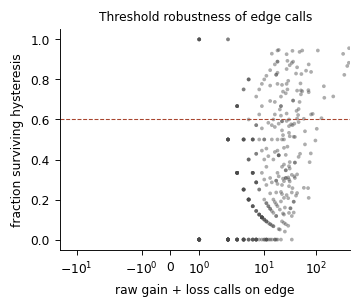

In [3]:
edges = core.edge_table(allp, allb, tree)
edges.to_csv(OUT / "edges_gain_loss.csv", index=False)
internal = edges[~edges.is_tip]

print(f"edges: {len(edges)}  ({len(internal)} internal, {edges.is_tip.sum()} tip)")
print("\nflicker zone (0.75 <= p <= 0.90):",
      f"{((asr >= .75) & (asr <= .90)).values.mean():.3%} of ancestral cells")
print("\nrobust fraction of gain/loss calls, internal edges:")
print(internal.frac_robust.describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(3.4, 2.6))
ax.scatter(internal.gain + internal.loss, internal.frac_robust, s=6, alpha=.45,
           color="#4a4a4a", edgecolor="none")
ax.axhline(0.6, ls="--", lw=.7, color=LOSS_COL)
ax.set_xscale("symlog"); ax.set_xlabel("raw gain + loss calls on edge")
ax.set_ylabel("fraction surviving hysteresis")
ax.set_title("Threshold robustness of edge calls", fontsize=8)
save(fig, "edge_threshold_robustness")

> **Read this before trusting any single edge.** The median internal edge has
> `frac_robust` ≈ 0.31 — most raw gain/loss calls do *not* survive hysteresis. Robustness
> concentrates on long, deep branches. Concretely, `node_1 → node_2` (Class I ancestor)
> retains 0.88 of its calls, whereas `node_6 → node_12`, which looks like the single
> largest loss event at face value, retains only ~0.31 and sits on a branch of length
> 0.13. Report strict counts as primary; the raw counts belong in a supplement.

## 3 · Fate of the parental repertoire at every bifurcation

For parent $P$ with children $A$, $B$:

| quantity | definition | reads as |
|---|---|---|
| `kept_both` | $P \cap A \cap B$ | conserved |
| `kept_one` | $P \cap (A \triangle B)$ | complementary retention → DDC |
| `lost_both` | $P \setminus (A \cup B)$ | loss |
| `novel_A` | $A \setminus (P \cup B)$ | private novelty → neofunctionalisation |

Indices: $\text{loss}=|lost\_both|/|P|$; $\text{sub}=|kept\_one|/|P\cap(A\cup B)|$;
$\text{neo}=(|novel_A|+|novel_B|)/|P\cup A\cup B|$. The `regime` label is the
arg-max and is heuristic — the three continuous indices are the real output, and a node
can score high on two at once (the root split does).

In [4]:
fates = core.fate_table(allb, tree)
fates.to_csv(OUT / "node_fates.csv", index=False)
print(fates.regime.value_counts().to_string())
print()
cols = ["node","n_parent","n_A","n_B","kept_both","kept_one","lost_both",
        "novel_A","novel_B","loss_index","sub_index","neo_index","regime"]
key_f = fates[fates.node.isin(KEY)].set_index("node").reindex(KEY).dropna(how="all")
print(key_f[cols[1:]].round(3).to_string())

regime
sub       243
neo       143
loss       26
static     19

         n_parent  n_A  n_B  kept_both  kept_one  lost_both  novel_A  novel_B  loss_index  sub_index  neo_index  regime
node                                                                                                                   
node_1         50   40   30          7        23         20       30        1       0.400      0.767      0.378     sub
node_2         40   53   42         20        15          5       19       11       0.125      0.429      0.400     sub
node_3         30   13   52         13        15          2        0       24       0.067      0.536      0.444     sub
node_4         53   42   64         36        16          1        4       12       0.019      0.308      0.229     sub
node_5         42   36   27         19        18          5        1        6       0.119      0.486      0.143     sub
node_6         52   49   23         19        24          9       10        0       0.173      0

### 3.1 · The Class I / Class II split is simultaneously sub- and neofunctionalising

At `node_1` the ancestral repertoire of 50 ligands is partitioned rather than inherited:
only 7 ligands go to both descendants, 23 go to exactly one (sub-index 0.77 — the DDC
signature of Force et al. 1999), and 20 are lost outright. On top of that partitioning,
the Class I ancestor privately acquires ~30 ligands while the Class II ancestor acquires
~1. Complementary degeneration and asymmetric innovation happened on the same edge.

wrote Figures/asr_fate_indices.svg


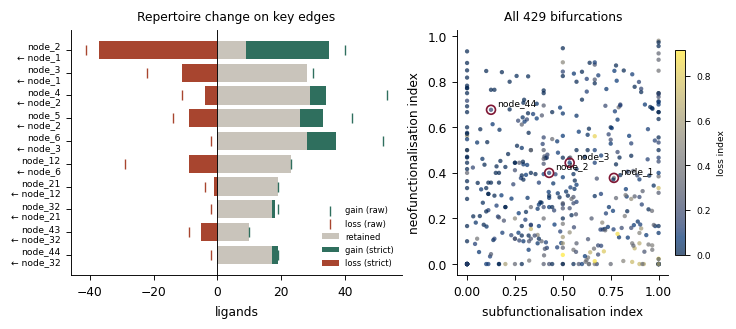

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), gridspec_kw={"width_ratios":[1.45,1]})

ax = axes[0]
ke = edges[edges.node.isin(KEY)].set_index("node").reindex(KEY).dropna(how="all")
y = np.arange(len(ke))
ax.barh(y, ke.retained, color=KEEP_COL, label="retained")
ax.barh(y, ke.gain_strict, left=ke.retained, color=GAIN_COL, label="gain (strict)")
ax.barh(y, -ke.loss_strict, color=LOSS_COL, label="loss (strict)")
ax.scatter(ke.retained + ke.gain, y, marker="|", s=40, color=GAIN_COL, lw=.9,
           label="gain (raw)")
ax.scatter(-ke.loss, y, marker="|", s=40, color=LOSS_COL, lw=.9, label="loss (raw)")
ax.set_yticks(y); ax.set_yticklabels([f"{n}\n← {p}" for n, p in
                                      zip(ke.index, ke.parent)], fontsize=6)
ax.axvline(0, color="k", lw=.6); ax.invert_yaxis()
ax.set_xlabel("ligands"); ax.set_title("Repertoire change on key edges", fontsize=8)
ax.legend(fontsize=5.5, frameon=False, loc="lower right")

ax = axes[1]
f = fates.dropna(subset=["sub_index","neo_index"])
ax.scatter(f.sub_index, f.neo_index, s=8, c=f.loss_index, cmap="cividis",
           alpha=.7, edgecolor="none")
for n in ["node_1","node_2","node_3","node_44"]:
    r = f[f.node == n]
    if len(r):
        ax.scatter(r.sub_index, r.neo_index, s=34, facecolor="none",
                   edgecolor="#7f1734", lw=1.1)
        ax.annotate(n, (r.sub_index.iloc[0], r.neo_index.iloc[0]),
                    fontsize=6, xytext=(4,3), textcoords="offset points")
sm = ax.collections[0]
cb = fig.colorbar(sm, ax=ax, fraction=.045, pad=.03); cb.set_label("loss index", size=6)
cb.ax.tick_params(labelsize=6)
ax.set_xlabel("subfunctionalisation index"); ax.set_ylabel("neofunctionalisation index")
ax.set_title(f"All {len(f)} bifurcations", fontsize=8)
save(fig, "asr_fate_indices")

## 4 · Seriated activation heatmap of the key nodes

Rows are in phylogenetic (pre-order) sequence, **not** clustered. Columns are seriated so
that nested repertoires form a staircase: ligands are sorted by how many key nodes
activate them, then lexicographically by the activation pattern read top-to-bottom. The
result makes containment (pure loss) visually distinct from turnover — a block that
shrinks from the right edge is attrition, a block that shifts sideways is replacement.

wrote Figures/asr_key_node_heatmap_seriated.svg


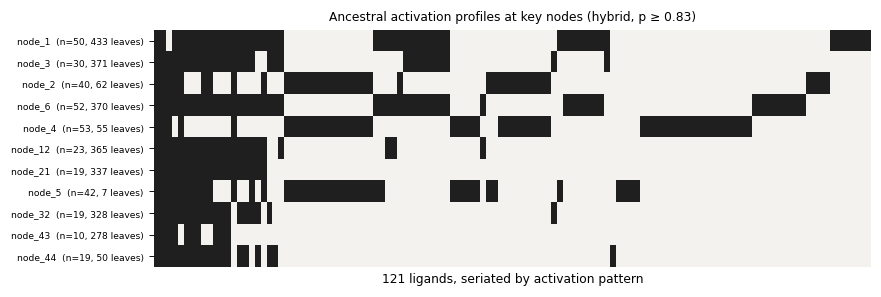

In [6]:
order = [n for n in allb.index if n in KEY]
order = sorted(order, key=lambda n: tree.depth[n])
sub = allb.loc[order]
sub = sub.loc[:, sub.sum(axis=0) > 0]
cols = core.seriate_columns(sub)
sub = sub[cols]

fig, ax = plt.subplots(figsize=(8.4, 2.8))
ax.imshow(sub.values, aspect="auto", cmap=mpl.colors.ListedColormap(["#f4f2ee", "#1f1f1f"]),
          interpolation="nearest")
ax.set_yticks(range(len(sub)))
ax.set_yticklabels([f"{n}  (n={int(sub.loc[n].sum())}, {tree.n_leaves(n)} leaves)"
                    for n in sub.index], fontsize=6)
ax.set_xticks([]); ax.set_xlabel(f"{sub.shape[1]} ligands, seriated by activation pattern")
ax.set_title("Ancestral activation profiles at key nodes (hybrid, p ≥ 0.83)", fontsize=8)
for s in ax.spines.values(): s.set_visible(False)
save(fig, "asr_key_node_heatmap_seriated")

## 5 · Functional vs phylogenetic distance

Jaccard alone conflates *turnover* with *repertoire-size difference*: a small set nested
inside a large one scores low Jaccard despite zero novelty. The overlap (Szymkiewicz–Simpson)
coefficient $|A\cap B| / \min(|A|,|B|)$ separates them — high overlap with low Jaccard
means containment, low both means replacement.

Significance uses a Mantel permutation test; the naive correlation p-value is invalid
because node pairs share tree structure and are not independent.

Mantel (patristic vs Jaccard distance): rho = +0.541, p = 0.0010, n = 250 nodes / 31,125 pairs
size-difference confound, Spearman(Jaccard, |ΔN|) = 0.582


wrote Figures/asr_functional_vs_phylo_distance.svg


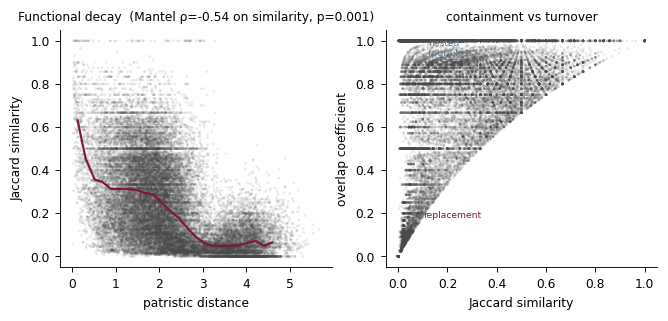

In [7]:
nodes = [n for n in allb.index if n.startswith("node_") and allb.loc[n].sum() > 0]
rng = np.random.default_rng(0)
samp = list(rng.choice(nodes, size=min(250, len(nodes)), replace=False))

V = allb.loc[samp].values.astype(bool)
inter = V.astype(int) @ V.T.astype(int)
sz = V.sum(axis=1)
union = sz[:, None] + sz[None, :] - inter
J = 1 - inter / np.maximum(union, 1)
OVL = inter / np.maximum(np.minimum(sz[:, None], sz[None, :]), 1)
D = np.array([[tree.patristic(a, b) for b in samp] for a in samp])

r_m, p_m = core.mantel(D, J, n_perm=999)
iu = np.triu_indices(len(samp), 1)
print(f"Mantel (patristic vs Jaccard distance): rho = {r_m:+.3f}, p = {p_m:.4f}, "
      f"n = {len(samp)} nodes / {len(iu[0]):,} pairs")
dz = np.abs(sz[:, None] - sz[None, :])
print("size-difference confound, Spearman(Jaccard, |ΔN|) =",
      round(stats.spearmanr(J[iu], dz[iu]).statistic, 3))

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
ax = axes[0]
ax.scatter(D[iu], 1 - J[iu], s=3, alpha=.12, color="#4a4a4a", edgecolor="none")
b = pd.cut(D[iu], np.linspace(0, np.percentile(D[iu], 99), 25))
m = pd.DataFrame({"d": D[iu], "s": 1 - J[iu], "b": b}).groupby("b", observed=True).median()
ax.plot(m.d, m.s, color=CLASS_I_COL, lw=1.4)
ax.set_xlabel("patristic distance"); ax.set_ylabel("Jaccard similarity")
ax.set_title(f"Functional decay  (Mantel ρ={-r_m:+.2f} on similarity, p={p_m:.3f})",
             fontsize=8)

ax = axes[1]
ax.scatter(1 - J[iu], OVL[iu], s=3, alpha=.12, color="#4a4a4a", edgecolor="none")
ax.set_xlabel("Jaccard similarity"); ax.set_ylabel("overlap coefficient")
ax.set_title("containment vs turnover", fontsize=8)
ax.annotate("nested\n(pure loss)", (.12, .93), fontsize=6, color=CLASS_II_COL)
ax.annotate("replacement", (.10, .18), fontsize=6, color=CLASS_I_COL)
save(fig, "asr_functional_vs_phylo_distance")

## 6 · Ancestor → tip: where does a modern receptor's repertoire come from?

For every human tip, each ligand in its repertoire is traced back along its ancestral
path to the **deepest** node at which it was already active. This partitions each modern
receptor's ligand set into inherited-from-root, acquired-en-route, and tip-private.

        n  f_root  f_private
cls                         
I    28.0   0.333      0.125
II   14.0   0.854      0.000

f_root, Class I vs II: Mann-Whitney p = 9.12e-12  (n = 59 vs 344)


wrote Figures/asr_tip_functional_origin.svg


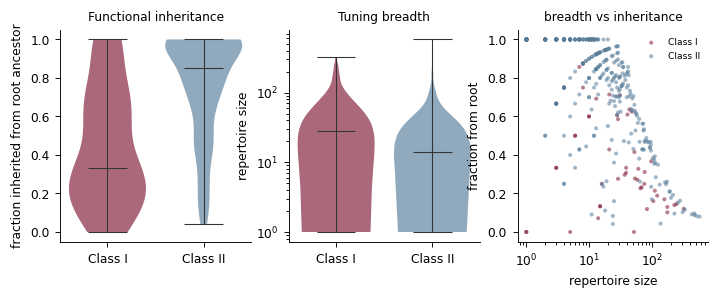

In [8]:
V = allb.values.astype(bool); pos = {n: i for i, n in enumerate(allb.index)}
rows = []
for t in tips.index:
    path = [x for x in tree.anc[t] if x in pos]          # tip → root
    if len(path) < 2: continue
    lig = np.where(V[pos[t]])[0]
    if len(lig) == 0: continue
    deepest = np.zeros(len(lig), dtype=int)
    for d, anc in enumerate(path):
        deepest = np.where(V[pos[anc]][lig], d, deepest)
    rows.append(dict(tip=t, n=len(lig), path_len=len(path),
                     from_root=int((deepest == len(path)-1).sum()),
                     tip_private=int((deepest == 0).sum()),
                     en_route=int(((deepest > 0) & (deepest < len(path)-1)).sum())))
origin = pd.DataFrame(rows)
origin["f_root"] = origin.from_root / origin.n
origin["f_private"] = origin.tip_private / origin.n
origin["cls"] = np.where(origin.tip.isin(CLASS_I), "I",
                  np.where(origin.tip.isin(CLASS_II), "II", "?"))
origin.to_csv(OUT / "tip_functional_origin.csv", index=False)

print(origin.groupby("cls")[["n", "f_root", "f_private"]].median().round(3).to_string())
u = stats.mannwhitneyu(origin.loc[origin.cls=="I","f_root"],
                       origin.loc[origin.cls=="II","f_root"])
print(f"\nf_root, Class I vs II: Mann-Whitney p = {u.pvalue:.3g}  "
      f"(n = {(origin.cls=='I').sum()} vs {(origin.cls=='II').sum()})")

fig, axes = plt.subplots(1, 3, figsize=(7.6, 2.5))
for ax, col, lab in zip(axes[:2], ["f_root", "n"],
                        ["fraction inherited from root ancestor", "repertoire size"]):
    data = [origin.loc[origin.cls == c, col] for c in ("I", "II")]
    parts = ax.violinplot(data, showmedians=True, widths=.8)
    for pc, c in zip(parts["bodies"], (CLASS_I_COL, CLASS_II_COL)):
        pc.set_facecolor(c); pc.set_alpha(.65); pc.set_edgecolor("none")
    for k in ("cbars","cmins","cmaxes","cmedians"):
        parts[k].set_color("#333"); parts[k].set_linewidth(.7)
    ax.set_xticks([1,2]); ax.set_xticklabels(["Class I","Class II"]); ax.set_ylabel(lab)
    if col == "n": ax.set_yscale("log")
axes[0].set_title("Functional inheritance", fontsize=8)
axes[1].set_title("Tuning breadth", fontsize=8)

ax = axes[2]
for c, col in (("I", CLASS_I_COL), ("II", CLASS_II_COL)):
    s = origin[origin.cls == c]
    ax.scatter(s.n, s.f_root, s=7, alpha=.55, color=col, edgecolor="none", label=f"Class {c}")
ax.set_xscale("log"); ax.set_xlabel("repertoire size"); ax.set_ylabel("fraction from root")
ax.legend(fontsize=6, frameon=False); ax.set_title("breadth vs inheritance", fontsize=8)
save(fig, "asr_tip_functional_origin")

## 7 · What kind of odorants are gained and lost?

Permutation enrichment (99,999 shuffles, right-tailed, Obs/Exp > 1) of odor tags in the
gained and lost ligand sets on the key edges. Background is the full 754-ligand panel.
Counts are small on individual edges, so `min_obs` guards against single-molecule tags.

In [9]:
tags = core.tag_map(odors, m2or)
bg = list(allb.columns)
res = []
for n in KEY:
    p = tree.parent.get(n)
    if p is None or p not in allb.index: continue
    c_b = allb.loc[n].astype(bool); p_b = allb.loc[p].astype(bool)
    c_p, p_p = allp.loc[n], allp.loc[p]
    gained = list(allb.columns[(~p_b) & c_b & (p_p <= LOW)])
    lost   = list(allb.columns[p_b & (~c_b) & (c_p <= LOW)])
    for label, s in (("gained", gained), ("lost", lost)):
        if len(s) < 5: continue
        e = core.tag_enrichment(s, bg, tags, n_perm=99999, min_obs=3)
        if len(e):
            e = e.assign(edge=f"{p}→{n}", direction=label, n_set=len(s))
            res.append(e)
enr = pd.concat(res, ignore_index=True) if res else pd.DataFrame()
if len(enr):
    enr["q"] = enr.groupby(["edge","direction"]).p.transform(
        lambda v: np.minimum.accumulate(
            (v.sort_values().values * len(v) / np.arange(1, len(v)+1))[::-1])[::-1][
            np.argsort(np.argsort(v.values))])
    enr.to_csv(OUT / "edge_odor_tag_enrichment.csv", index=False)
    print(enr[enr.p <= .01][["edge","direction","tag","obs","total","exp","obs_exp","p"]]
          .round(3).to_string(index=False))
else:
    print("no enriched tags at these thresholds")

          edge direction     tag  obs  total   exp  obs_exp     p
 node_1→node_2    gained   fatty   10    108 3.724    2.685 0.002
 node_1→node_2    gained  cheesy    6     42 1.448    4.143 0.002
 node_1→node_2    gained    sour    4     18 0.621    6.444 0.003
 node_1→node_2    gained    waxy    9     96 3.310    2.719 0.003
 node_1→node_2      lost    plum    4     11 0.540    7.410 0.001
 node_1→node_2      lost tobacco    4     11 0.540    7.410 0.001
 node_1→node_2      lost   woody   10     81 3.975    2.516 0.004
 node_1→node_2      lost   amber    3      8 0.393    7.642 0.005
 node_1→node_2      lost  violet    3      9 0.442    6.793 0.007
 node_2→node_5    gained    rose    4     50 0.464    8.617 0.000
 node_2→node_5    gained  floral    6    154 1.430    4.197 0.001
node_6→node_12      lost  coffee    3     25 0.298   10.053 0.003
node_6→node_12      lost   meaty    3     39 0.466    6.444 0.008


wrote Figures/asr_edge_tag_enrichment.svg


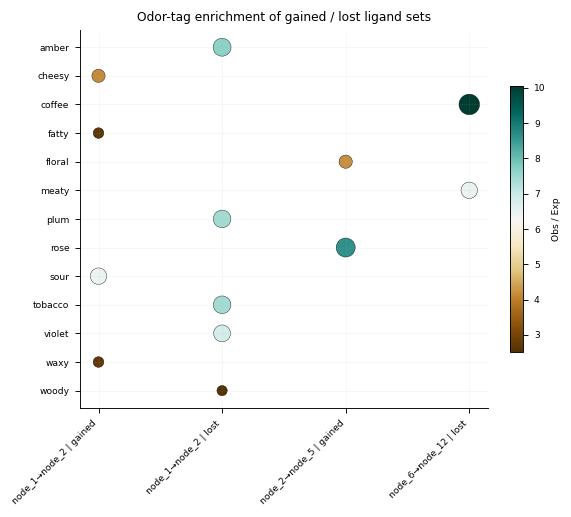

In [10]:
if len(enr):
    top = enr[enr.p <= .01].copy()
    top["lab"] = top.edge + " | " + top.direction
    piv = top.pivot_table(index="tag", columns="lab", values="obs_exp")
    piv = piv.loc[piv.notna().sum(axis=1).sort_values(ascending=False).index]
    fig, ax = plt.subplots(figsize=(max(4, .55*piv.shape[1]+3), .22*len(piv)+1.6))
    X, Y = np.meshgrid(np.arange(piv.shape[1]), np.arange(piv.shape[0]))
    v = piv.values
    sc = ax.scatter(X[~np.isnan(v)], Y[~np.isnan(v)], s=18*v[~np.isnan(v)],
                    c=v[~np.isnan(v)], cmap="BrBG", edgecolor="k", linewidth=.25)
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=45,
                                                           ha="right", fontsize=6)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=6)
    ax.invert_yaxis(); ax.grid(alpha=.15, lw=.4)
    cb = fig.colorbar(sc, ax=ax, fraction=.03); cb.set_label("Obs / Exp", size=6)
    cb.ax.tick_params(labelsize=6)
    ax.set_title("Odor-tag enrichment of gained / lost ligand sets", fontsize=8)
    save(fig, "asr_edge_tag_enrichment")

### 7.1 · Interpretation — the Class I ancestor acquires an acid signature

The gains on `node_1 → node_2` are enriched for **fatty, cheesy, sour and waxy** tags,
i.e. short-chain carboxylic acids and their fermentation products, while the losses are
enriched for **woody, amber, violet, plum, tobacco** — heavier, more hydrophobic
terpenoid-type compounds. Nothing in the pipeline was told which receptors are Class I.

This recapitulates the independently established chemical division of the two classes:
Class I receptors are the water-soluble / hydrophilic-ligand branch and Class II the
volatile / hydrophobic branch (Niimura 2012; Silva et al. 2023 *J Genet Genomics*). The
single high-resolution OR structure available — OR51E2, a Class I receptor, bound to
propionate (Billesbølle et al. 2023 *Nature*) — is exactly a short-chain fatty acid, so
there is a direct experimental anchor for the predicted ancestral acid preference.

Because this is a chemical signature recovered from sequence-based predictions rather
than imposed, it is a model-independent consistency check, and it is the strongest
argument that the ancestral profiles carry real signal rather than reconstruction noise.
It also pairs naturally with the planned RDKit descriptor analysis: if the gained set is
significantly more hydrophilic (lower cLogP, higher TPSA) than the lost set, the tag-level
result gets a physicochemical backbone.

## 8 · Tree figures

Branches coloured by hysteresis-filtered turnover, node markers sized by repertoire and
coloured by net change. Drawn directly in matplotlib so the output is a clean SVG that
drops into the existing figure pipeline.

wrote Figures/asr_tree_turnover.svg


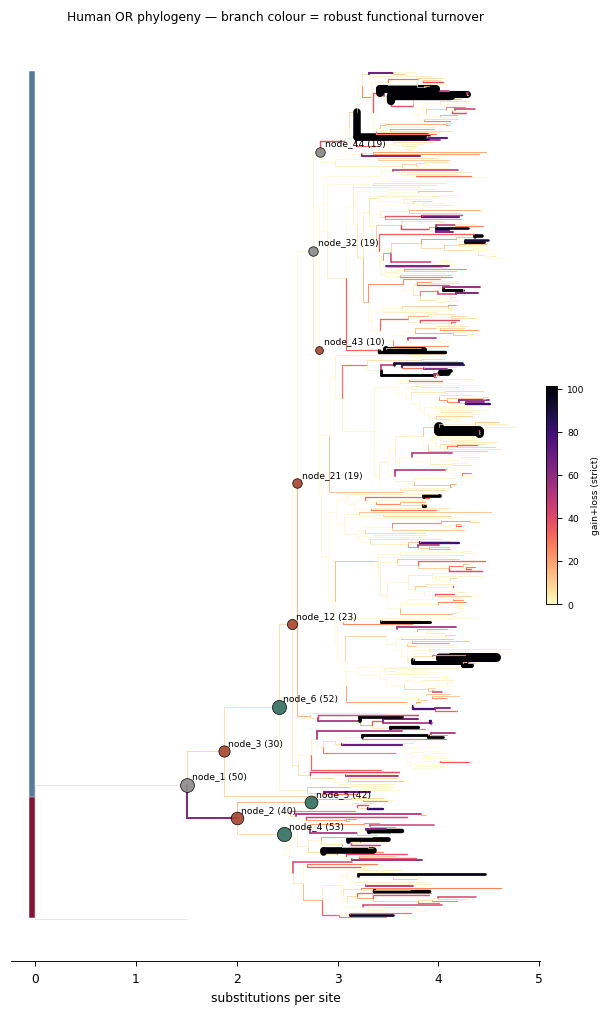

In [11]:
def layout(tree, root="node_0"):
    ys, order, counter = {}, [], [0]
    def rec(n):
        kids = [c for c in tree.children.get(n, []) if c]
        if not kids:
            ys[n] = counter[0]; counter[0] += 1; order.append(n); return ys[n]
        vals = [rec(c) for c in kids]
        ys[n] = float(np.mean(vals)); order.append(n); return ys[n]
    rec(root)
    return ys, order

ys, _ = layout(tree)
emap = edges.set_index("node")

fig, ax = plt.subplots(figsize=(6.4, 11))
norm = mpl.colors.Normalize(0, np.percentile(edges.turnover, 97))
cmap = mpl.cm.get_cmap("magma_r")
for n in tree.node:
    p = tree.parent.get(n)
    if p is None: continue
    x0, x1, y0, y1 = tree.depth[p], tree.depth[n], ys[p], ys[n]
    t = emap.turnover.get(n, np.nan)
    col = cmap(norm(t)) if not np.isnan(t) else "#d8d5d0"
    lw = 0.35 + 1.5 * (0 if np.isnan(t) else norm(t))
    ax.plot([x0, x0], [y0, y1], color=col, lw=lw, solid_capstyle="round")
    ax.plot([x0, x1], [y1, y1], color=col, lw=lw, solid_capstyle="round")

for n in KEY:
    if n not in allb.index: continue
    net = emap.net.get(n, 0)
    ax.scatter(tree.depth[n], ys[n], s=12 + 1.4*allb.loc[n].sum(),
               facecolor=(GAIN_COL if net > 0 else LOSS_COL if net < 0 else "#888"),
               edgecolor="k", lw=.5, zorder=5, alpha=.9)
    ax.annotate(f"{n} ({int(allb.loc[n].sum())})", (tree.depth[n], ys[n]),
                fontsize=6, xytext=(3, 4), textcoords="offset points", zorder=6)

for c, col, lab in ((CLASS_I, CLASS_I_COL, "Class I"), (CLASS_II, CLASS_II_COL, "Class II")):
    yy = [ys[t] for t in c if t in ys]
    ax.add_patch(Rectangle((ax.get_xlim()[1]*0.0 - .05, min(yy)), .04, max(yy)-min(yy),
                           color=col, clip_on=False))
ax.set_yticks([]); ax.set_xlabel("substitutions per site")
ax.set_title("Human OR phylogeny — branch colour = robust functional turnover", fontsize=8)
for s in ("left","right","top"): ax.spines[s].set_visible(False)
cb = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
                  fraction=.02, pad=.01); cb.set_label("gain+loss (strict)", size=6)
cb.ax.tick_params(labelsize=6)
save(fig, "asr_tree_turnover")

### 8.1 · TreeProfiler / ETE-4 export

TreeProfiler is a CLI that annotates a tree from a metadata TSV, so the useful artifact is
a correctly-keyed annotation table rather than a plot made here. Run on nada-P8:

```bash
treeprofiler annotate \
  --tree PF13853_9606_7764_mafft_lg_treefile_rooted.withinternalnames \
  --input-type newick --metadata Tables/treeprofiler_annotation.tsv \
  --outdir tp_out
treeprofiler plot --tree tp_out/*_annotated.nw \
  --barplot-layout repertoire --heatmap-layout turnover,neo_index,sub_index,loss_index \
  --column-summary-method none
```

In [12]:
ann = edges[["node","n_child","gain_strict","loss_strict","turnover","net",
             "jaccard_pc","frac_robust","blen","n_leaves"]].rename(
        columns={"n_child":"repertoire"})
ann = ann.merge(fates[["node","neo_index","sub_index","loss_index","regime"]],
                on="node", how="left")
ann.insert(0, "name", ann.pop("node"))
ann["class"] = np.where(ann.name.isin(CLASS_I), "I",
                 np.where(ann.name.isin(CLASS_II), "II", "internal"))
ann.to_csv(OUT / "treeprofiler_annotation.tsv", sep="\t", index=False)
print(ann.head().to_string(index=False))
print("\nwrote", OUT / "treeprofiler_annotation.tsv", "|", ann.shape)

try:
    from ete4 import Tree as ETree
    et = ETree(open(TREEFILE).read(), parser=1)
    print("ete4 parsed:", len(list(et.leaves())), "leaves — "
          "use et.explore() for the interactive view")
except Exception as e:
    print("ete4 unavailable in this kernel:", e)

    name  repertoire  gain_strict  loss_strict  turnover  net  jaccard_pc  frac_robust     blen  n_leaves  neo_index  sub_index  loss_index regime    class
node_100          39            0            7         7  -35    0.506667     0.189189 0.109557         2   0.000000   0.200000    0.615385   loss internal
node_101          59            1            1         2   -2    0.690141     0.090909 0.075188         6   0.000000   1.000000    0.728814    sub internal
node_102          59            7            4        11   -2    0.558442     0.323529 0.082288        35   0.825397   0.258621    0.016949    neo internal
node_103           2            0            0         0    0    1.000000          NaN 0.155341         4   0.956522   1.000000    0.000000    sub internal
node_104          17            9            0         9   15    0.117647     0.600000 0.100237         6   0.491525   0.785714    0.176471    sub internal

wrote Tables/treeprofiler_annotation.tsv | (864, 15)
ete4 parse

## 10 · Chemistry of the gains and losses

Functional groups via SMARTS (Fisher exact, BH-FDR) and physicochemical descriptors
(Mann-Whitney + Cliff's delta) for the hysteresis-filtered gained and lost sets on each
key edge, against the full 754-ligand panel.

In [13]:
# import chem  (inlined in setup)
sm = m2or[["SMILES","smiles_id"]].drop_duplicates().set_index("smiles_id").SMILES.to_dict()
feats = chem.featurise(sm)
print("featurised", feats.shape)

def edge_sets(n):
    p = tree.parent[n]
    cb, pb = allb.loc[n].astype(bool), allb.loc[p].astype(bool)
    gained = list(allb.columns[(~pb) & cb & (allp.loc[p] <= LOW)])
    lost   = list(allb.columns[pb & (~cb) & (allp.loc[n] <= LOW)])
    return p, gained, lost

bg = list(allb.columns)
fg_all, ds_all = [], []
for n in KEY:
    if n not in tree.parent or tree.parent[n] not in allb.index: continue
    p, g, l = edge_sets(n)
    for lab, s in (("gained", g), ("lost", l)):
        if len(s) < 5: continue
        f = chem.fg_test(s, bg, feats)
        d = chem.desc_test(s, bg, feats)
        if len(f): fg_all.append(f.assign(edge=f"{p}→{n}", direction=lab, n_set=len(s)))
        if len(d): ds_all.append(d.assign(edge=f"{p}→{n}", direction=lab))
fg_all = pd.concat(fg_all, ignore_index=True); ds_all = pd.concat(ds_all, ignore_index=True)
fg_all.to_csv(OUT/"edge_functional_groups.csv", index=False)
ds_all.to_csv(OUT/"edge_descriptors.csv", index=False)
print(fg_all[fg_all.q <= .05][["edge","direction","group","obs","n_set","total","obs_exp","q"]]
      .round(3).to_string(index=False))

featurised (754, 33)


          edge direction           group  obs  n_set  total  obs_exp     q
 node_1→node_2    gained carboxylic_acid   23     26     83    8.036 0.000
 node_1→node_2    gained         halogen    5     26     15    9.667 0.001
 node_1→node_2    gained           ester    0     26    158    0.000 0.017
 node_1→node_2    gained           ether    2     26    245    0.237 0.022
 node_1→node_2    gained          ketone    0     26    129    0.000 0.045
 node_1→node_2    gained  terpenoid_like    0     26    131    0.000 0.045
 node_1→node_2      lost          ketone   18     37    129    2.843 0.000
 node_1→node_2      lost  terpenoid_like   18     37    131    2.800 0.000
 node_1→node_2      lost  heteroaromatic    8     37     63    2.588 0.045
 node_1→node_2      lost   aromatic_ring   16     37    183    1.782 0.045
 node_1→node_3      lost   aromatic_ring    8     11    183    2.997 0.017
 node_2→node_4    gained carboxylic_acid    5      5     83    9.084 0.000
 node_2→node_5      lost 

### 10.1 · The Class I ancestor acquires carboxylic acids and sheds ketones/terpenoids

23 of the 26 ligands gained on `node_1 → node_2` are carboxylic acids (Obs/Exp = 8.0,
q < 0.001), with esters, ketones, alcohols and terpenoid-like skeletons all significantly
*depleted* — zero of each. The losses on the same edge are enriched for ketones (2.8×),
terpenoid-like skeletons (2.8×) and aromatic rings. `node_2 → node_4` doubles down: all
five gains are acids. Within Class I, `node_2 → node_5` reverses it, losing acids (6 of 9).

In Class II the polar acquisition happens through nitrogen instead: `node_3 → node_6`
gains amines and heteroaromatics (Obs/Exp 10.5 and 5.3).

**The shift is hydrogen bonding, not hydrophobicity.** Contrasting gained against lost
directly at the Class I ancestor: HBD (Cliff δ = +0.80, p = 2×10⁻⁹) and TPSA
(δ = +0.75, p = 2×10⁻⁷) separate cleanly, while **cLogP does not differ at all**
(p = 0.39) and neither does MW (p = 0.96). So this is not the crude "Class I =
water-soluble" story — at matched lipophilicity and size, the ancestral Class I receptor
switched to ligands bearing hydrogen-bond-donating headgroups. That maps onto the known
mechanism better than a solubility argument would: OR51E2 binds propionate through polar
contacts, not hydrophobic burial (Billesbølle et al. 2023 *Nature*).

descriptor   gained     lost  cliffs_delta      p
     cLogP   2.8326   2.8443       -0.1289 0.3905
        MW 171.2600 190.1980        0.0094 0.9555
      TPSA  37.3000  17.0700        0.7505 0.0000
       HBD   1.0000   0.0000        0.7963 0.0000
       HBA   1.0000   1.0000       -0.0946 0.4296
   nArRing   0.0000   1.0000       -0.3669 0.0056
  FracCSP3   0.8333   0.4615        0.4283 0.0041
      nRot   5.0000   2.0000        0.6237 0.0000


wrote Figures/asr_classI_chemistry_swap.svg


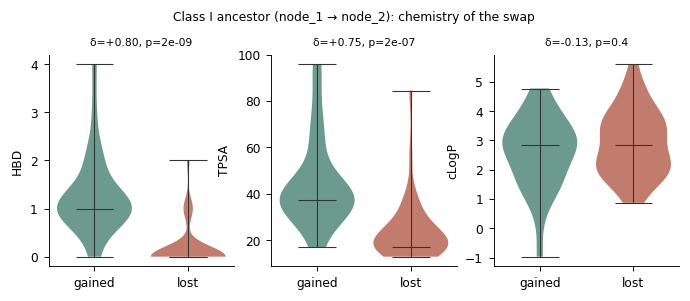

In [14]:
n = "node_2"; p, g, l = edge_sets(n)
rows = []
for d in ["cLogP","MW","TPSA","HBD","HBA","nArRing","FracCSP3","nRot"]:
    x = feats.loc[[s for s in g if s in feats.index], d]
    y = feats.loc[[s for s in l if s in feats.index], d]
    u = stats.mannwhitneyu(x, y)
    rows.append(dict(descriptor=d, gained=x.median(), lost=y.median(),
                     cliffs_delta=2*u.statistic/(len(x)*len(y))-1, p=u.pvalue))
contrast = pd.DataFrame(rows)
print(contrast.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.5))
for ax, d in zip(axes, ["HBD", "TPSA", "cLogP"]):
    x = feats.loc[[s for s in g if s in feats.index], d]
    y = feats.loc[[s for s in l if s in feats.index], d]
    parts = ax.violinplot([x, y], showmedians=True, widths=.8)
    for pc, c in zip(parts["bodies"], (GAIN_COL, LOSS_COL)):
        pc.set_facecolor(c); pc.set_alpha(.7); pc.set_edgecolor("none")
    for kk in ("cbars","cmins","cmaxes","cmedians"):
        parts[kk].set_color("#333"); parts[kk].set_linewidth(.7)
    r = contrast[contrast.descriptor == d].iloc[0]
    ax.set_xticks([1,2]); ax.set_xticklabels(["gained","lost"])
    ax.set_ylabel(d); ax.set_title(f"δ={r.cliffs_delta:+.2f}, p={r.p:.1g}", fontsize=7)
fig.suptitle("Class I ancestor (node_1 → node_2): chemistry of the swap", fontsize=8, y=1.04)
save(fig, "asr_classI_chemistry_swap")

## 11 · Does expansion buy redundancy or discrimination?

Neither gene counts nor per-receptor breadth answer this. The question is about the
**combinatorial code**: as lineages accumulate, do the added receptors detect chemicals
nothing else detected (coverage), split chemicals that previously shared an activation
pattern (discrimination), or simply pile more receptors onto ligands already encoded
(redundancy)?

The analysis is a time-slice of the tree. Ordering internal nodes by root distance, the
k-th split leaves k+1 co-existing lineages; taking each lineage's ancestral profile gives
the repertoire *as it stood* at that stage. At every stage we measure

- **coverage** — ligands bound by at least one receptor
- **distinct patterns** — unique activation vectors among covered ligands, i.e. how many
  chemicals the code can actually tell apart
- **redundancy** — mean receptors per covered ligand

against a row-shuffle null in which each receptor keeps its tuning breadth but ligands
become independent. That null is the efficient frontier: the discrimination this many
receptors *could* deliver if duplicates were not correlated.

In [15]:
slices = chem.lineage_slices(tree, allb)
slices.to_csv(OUT/"lineage_slices.csv", index=False)
print(slices.iloc[[0,2,4,9,19,49,99,199,299,len(slices)-1]]
      [["k","coverage","distinct_patterns","mean_receptors_per_ligand","discriminability"]]
      .round(3).to_string(index=False))

slices["d_pat"] = slices.distinct_patterns.diff()
slices["d_cov"] = slices.coverage.diff()
print("marginal return per added lineage:")
for lo, hi in [(2,10),(10,50),(50,100),(100,200),(200,433)]:
    s = slices[(slices.k >= lo) & (slices.k < hi)]
    print(f"  k {lo:>3}-{hi:<3}  +{s.d_pat.mean():>5.2f} patterns  "
          f"+{s.d_cov.mean():>5.2f} newly covered ligands")

  k  coverage  distinct_patterns  mean_receptors_per_ligand  discriminability
  2        62                  3                      1.129             0.048
  4       107                  9                      1.495             0.084
  6       122                 15                      1.910             0.123
 11       127                 43                      2.740             0.339
 21       194                 81                      3.768             0.418
 51       420                176                      4.376             0.419
101       590                295                      6.432             0.500
201       653                474                     12.763             0.726
301       666                548                     16.868             0.823
433       731                603                     21.480             0.825
marginal return per added lineage:
  k   2-10   + 4.29 patterns  + 7.71 newly covered ligands
  k  10-50   + 3.45 patterns  + 7.55 newly cover

  k  coverage  pat_obs  pat_null  pat_null_sd  efficiency
 11       127       43     47.60        2.956       0.903
 51       420      176    492.65        8.469       0.357
101       590      295    739.40        3.652       0.399
201       653      474    754.00        0.000       0.629
301       666      548    754.00        0.000       0.727
433       731      603    754.00        0.000       0.800


wrote Figures/asr_redundancy_vs_discrimination.svg


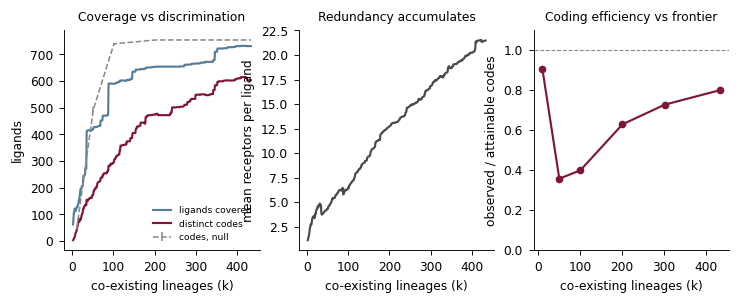

In [16]:
# efficient frontier: row-shuffle null
rng = np.random.default_rng(0)
def code_stats(V):
    cov = V.any(axis=0); P = V[:, cov]
    return int(cov.sum()), len({tuple(P[:, j]) for j in range(P.shape[1])})

internal = sorted([n for n in tree.node if not tree.is_tip(n) and n in allb.index],
                  key=lambda n: tree.depth[n])
live, snap = [internal[0]], {}
for nd in internal:
    if nd not in live: continue
    kids = [c for c in tree.children[nd] if c in allb.index]
    if len(kids) < 2: continue
    live = [x for x in live if x != nd] + kids
    snap[len(live)] = list(live)

null_rows = []
for k in [11, 51, 101, 201, 301, max(snap)]:
    V = allb.loc[snap[k]].values.astype(bool)
    co, po = code_stats(V)
    nl = [code_stats(np.array([rng.permutation(r) for r in V]))[1] for _ in range(20)]
    null_rows.append(dict(k=k, coverage=co, pat_obs=po,
                          pat_null=np.mean(nl), pat_null_sd=np.std(nl),
                          efficiency=po/np.mean(nl)))
nulls = pd.DataFrame(null_rows)
nulls.to_csv(OUT/"code_efficiency_null.csv", index=False)
print(nulls.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(7.8, 2.6))
ax = axes[0]
ax.plot(slices.k, slices.coverage, color=CLASS_II_COL, lw=1.4, label="ligands covered")
ax.plot(slices.k, slices.distinct_patterns, color=CLASS_I_COL, lw=1.4,
        label="distinct codes")
ax.errorbar(nulls.k, nulls.pat_null, yerr=nulls.pat_null_sd, fmt="--", lw=1.0,
            color="#888", label="codes, null")
ax.set_xlabel("co-existing lineages (k)"); ax.set_ylabel("ligands")
ax.legend(fontsize=6, frameon=False); ax.set_title("Coverage vs discrimination", fontsize=8)

ax = axes[1]
ax.plot(slices.k, slices.mean_receptors_per_ligand, color="#4a4a4a", lw=1.4)
ax.set_xlabel("co-existing lineages (k)"); ax.set_ylabel("mean receptors per ligand")
ax.set_title("Redundancy accumulates", fontsize=8)

ax = axes[2]
ax.plot(nulls.k, nulls.efficiency, "o-", color=CLASS_I_COL, lw=1.4, ms=4)
ax.axhline(1.0, ls="--", lw=.7, color="#888")
ax.set_ylim(0, 1.1); ax.set_xlabel("co-existing lineages (k)")
ax.set_ylabel("observed / attainable codes")
ax.set_title("Coding efficiency vs frontier", fontsize=8)
save(fig, "asr_redundancy_vs_discrimination")

### 11.1 · Answer: coverage first, then discrimination, with heavy redundancy throughout

Coverage saturates early — by k ≈ 100 lineages, 590 of 754 ligands are already detected,
and the remaining 330 lineages add only ~140 more, dropping to +0.34 newly covered ligands
per lineage at the end. Distinct codes keep growing (295 → 603) but with marginal return
falling from +4.3 to +0.55 per lineage, while redundancy climbs monotonically from 1.1 to
21.5 receptors per ligand.

Against the frontier the verdict is blunt: a *random* repertoire of 201 receptors with the
same tuning breadths discriminates all 754 ligands perfectly (null = 754.0, sd = 0). The
real repertoire needs 433 receptors to reach 603, i.e. 80% of attainable, and dips to 36%
of attainable around k = 51. Duplication produces receptors whose codes are correlated with
their sisters', so each addition buys far less discrimination than an independent receptor
would.

This is the ligand-level version of the prediction implicit in Nei, Niimura & Nozawa
(2008): if expansion were optimising discrimination, the repertoire should track the
frontier. It does not.

> **The caveat that governs how hard you can push this.** Correlated predictions produce
> correlated codes by construction — if ESM-C embeds sister sequences similarly, the model
> will assign them similar profiles whether or not the real receptors are redundant. This
> analysis is the single most exposed to that artifact, because the artifact biases in
> exactly the direction of the conclusion. The model-free control is to repeat the
> efficiency calculation on the 23,782 experimentally measured M2OR pairs alone: if real
> co-tuning among measured human receptors also falls well short of the shuffle frontier,
> the redundancy result survives. Do that before this goes in a manuscript.
>
> Two further limits: the model's known optimism inflates both coverage and redundancy,
> and the 754-ligand panel reflects what has been assayed rather than a fair sample of
> chemical space, so absolute saturation points should not be read literally.

## 9 · Summary table for the manuscript

In [17]:
summary = (edges[edges.node.isin(KEY)]
           .merge(fates[["node","neo_index","sub_index","loss_index","regime"]],
                  on="node", how="left")
           .set_index("node").reindex(KEY).dropna(how="all"))
cols = ["parent","blen","n_leaves","n_parent","n_child","gain_strict","loss_strict",
        "retained","jaccard_pc","frac_robust","neo_index","sub_index","loss_index","regime"]
summary[cols].round(3).to_csv(OUT / "key_node_summary.csv")
print(summary[cols].round(3).to_string())

          parent   blen  n_leaves  n_parent  n_child  gain_strict  loss_strict  retained  jaccard_pc  frac_robust  neo_index  sub_index  loss_index  regime
node                                                                                                                                                       
node_2    node_1  0.487      62.0      50.0     40.0         26.0         37.0       9.0       0.111        0.875      0.400      0.429       0.125     sub
node_3    node_1  0.357     371.0      50.0     30.0          0.0         11.0      28.0       0.538        0.458      0.444      0.536       0.067     sub
node_4    node_2  0.473      55.0      40.0     53.0          5.0          4.0      29.0       0.453        0.257      0.229      0.308       0.019     sub
node_5    node_2  0.738       7.0      40.0     42.0          7.0          9.0      26.0       0.464        0.533      0.143      0.486       0.119     sub
node_6    node_3  0.547     370.0      30.0     52.0          9.

## 12 · Measured-only control (M2OR) — is the redundancy real or a model artifact?

Section 11 showed the predicted repertoire falls far below the discrimination frontier.
The stated risk was that the model may give similar sequences similar profiles,
**manufacturing** redundancy. This section repeats the logic on the 25,044 experimentally
measured wild-type human pairs in M2OR, with no predictions used.

Two features of the measured data must be handled first, and one of them is a genuine
finding about the database.

### 12.1 · Is there a bias in where the 1's are?

Yes, a strong and structured one, in two directions:

- **Receptor side — targeted deorphanisation.** The more ligands a receptor was tested
  against, the *higher* its hit rate (Spearman ρ ≈ +0.61). Receptors tested against 1–10
  ligands have a mean hit rate near 0; those tested against 60+ sit near 0.045. Receptors
  were not sampled at random — they were pursued once a binder looked likely.

- **Ligand side — publication bias at low coverage.** The more receptors a ligand was
  tested against, the *lower* its hit rate (ρ ≈ −0.34). The signature is stark: of the 189
  ligands tested against exactly **one** receptor, **68% are positive**, versus a 4.6%
  baseline across all measured cells. A singly-tested pair in M2OR is almost always a
  *reported hit* from a targeted paper; isolated negatives rarely get published.

**Consequences for the analysis.** (1) Missing ≠ non-binding, so we cannot treat blank
cells as zeros. (2) The low-coverage singletons carry the publication bias, so they are
excluded by restricting to a densely-measured sub-block. (3) The frontier shuffle is
**mask-aware** — each receptor's outcomes are permuted only among the cells it was
actually measured on — so sampling structure is held fixed and only co-tuning is
destroyed.

       rho_receptor_ntested_vs_hitrate: 0.607
         rho_ligand_ntested_vs_hitrate: -0.344
                   n_singleton_ligands: 189
               singleton_positive_rate: 0.683
                baseline_positive_rate: 0.046


wrote Figures/m2or_measurement_bias.svg


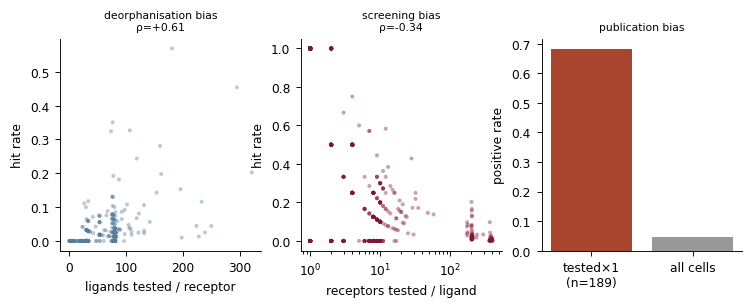

In [18]:
# import m2or_control as mc  (inlined in setup)
piv = mc.measured_matrix(wt_only=True)
bias = mc.bias_report(piv)
for k, v in bias.items():
    print(f"{k:>38}: {v:.3f}" if isinstance(v, float) else f"{k:>38}: {v}")

meas = piv.notna(); pos = (piv == 1)
rm, rhr = meas.sum(axis=1), pos.sum(axis=1) / meas.sum(axis=1).replace(0, np.nan)
lm, lhr = meas.sum(axis=0), pos.sum(axis=0) / meas.sum(axis=0).replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(8.0, 2.5))
axes[0].scatter(rm, rhr, s=7, alpha=.4, color=CLASS_II_COL, edgecolor="none")
axes[0].set_xlabel("ligands tested / receptor"); axes[0].set_ylabel("hit rate")
axes[0].set_title(f"deorphanisation bias\nρ={bias['rho_receptor_ntested_vs_hitrate']:+.2f}", fontsize=7)
axes[1].scatter(lm, lhr, s=7, alpha=.4, color=CLASS_I_COL, edgecolor="none")
axes[1].set_xscale("log"); axes[1].set_xlabel("receptors tested / ligand"); axes[1].set_ylabel("hit rate")
axes[1].set_title(f"screening bias\nρ={bias['rho_ligand_ntested_vs_hitrate']:+.2f}", fontsize=7)
n1 = int(meas.sum(axis=0).eq(1).sum())
axes[2].bar([0, 1], [bias["singleton_positive_rate"], bias["baseline_positive_rate"]],
            color=[LOSS_COL, "#999"])
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels([f"tested×1\n(n={n1})", "all cells"])
axes[2].set_ylabel("positive rate"); axes[2].set_title("publication bias", fontsize=7)
save(fig, "m2or_measurement_bias")

### 12.2 · Densest measured sub-block

Iteratively drop receptors and ligands with fewer than 25 mutual measurements. The block
stabilises at ~385 receptors × 90 ligands, 62% measured — a matrix where blanks are the
minority and the code question is well-posed. The result is stable across the 20/25/30
thresholds (efficiency 0.93–0.95, redundancy ~7).

In [19]:
block = mc.dense_block(piv, T=25)
print(f"dense block: {block.shape}, density {block.notna().values.mean():.2f}, "
      f"positives {int((block.values == 1).sum())}")
accum = mc.accumulation_measured(block, n_perm_order=40, n_shuffle=15, seed=0)
accum.to_csv(OUT / "m2or_accumulation.csv", index=False)
chk = accum[accum.frontier.notna()]
print(chk[["n_receptors","coverage","distinct","frontier","efficiency","redundancy"]]
      .round(2).to_string(index=False))

dense block: (385, 90), density 0.62, positives 622


 n_receptors  coverage  distinct  frontier  efficiency  redundancy
           1      1.32      0.35      0.35        1.00        0.35
          97     58.15     51.22     70.42        0.73        2.66
         193     74.38     68.85     85.01        0.81        4.17
         289     81.53     77.28     88.00        0.88        5.68
         385     87.00     83.00     89.02        0.93        7.15


### 12.3 · Head-to-head on an identical block

The cleanest test: take the same receptors × ligands, evaluate on the same measured-cell
mask, and compare the **pure predicted** matrix (probabilities ≥ 0.83, *no* M2OR override)
against the measured truth.

pure-predicted vs measured on 20,207 measured cells:
  agreement 0.952 | recall 0.72 | precision 0.35



           coverage  distinct  redundancy  frontier  efficiency
measured       87.0      83.0        6.75     88.83        0.93
predicted      79.0      76.0       15.41     89.97        0.84


wrote Figures/m2or_control_summary.svg


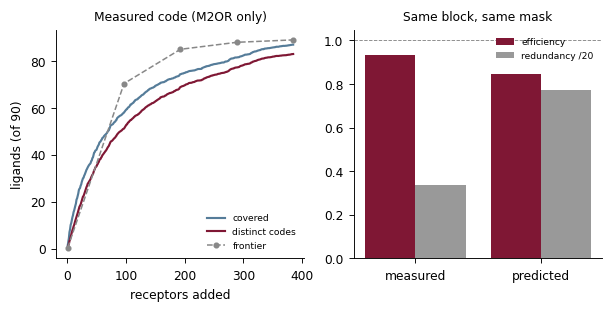

In [20]:
rows = [i for i in ref.index if str(i).startswith("9606.")]
pred_bin = (ref.loc[rows] >= THRESH).astype(int)
hum = {k: v for k, v in fasta.items() if k.startswith("9606.")}
seq2pid = {v: k for k, v in hum.items()}
ok = [(s, seq2pid.get(s)) for s in block.index if seq2pid.get(s) in pred_bin.index]
seqs = [s for s, _ in ok]; pids = [p for _, p in ok]
ligs = [c for c in block.columns if c in pred_bin.columns]
pred = pred_bin.loc[pids, ligs]; measb = block.loc[seqs, ligs]
mask = measb.notna().values
Bp, Bm = (pred.values == 1), (measb.fillna(0).values == 1)

tp = int(((Bp & Bm) & mask).sum()); fp = int(((Bp & ~Bm) & mask).sum())
fn = int(((~Bp & Bm) & mask).sum()); tn = int(((~Bp & ~Bm) & mask).sum())
print(f"pure-predicted vs measured on {int(mask.sum()):,} measured cells:")
print(f"  agreement {(tp+tn)/mask.sum():.3f} | recall {tp/(tp+fn):.2f} | precision {tp/(tp+fp):.2f}")

rng = np.random.default_rng(0)
def eff(B, mask, n=30):
    c, p, d = mc.code_stats(B, mask)
    fr = np.mean([mc.code_stats(mc.masked_row_shuffle(B, mask, rng), mask)[1] for _ in range(n)])
    return dict(coverage=c, distinct=p, redundancy=d, frontier=fr, efficiency=p/fr)
em, ep = eff(Bm, mask), eff(Bp, mask)
comp = pd.DataFrame({"measured": em, "predicted": ep}).T
comp.to_csv(OUT / "m2or_vs_predicted_efficiency.csv")
print(); print(comp.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.7))
ax = axes[0]
ax.plot(accum.n_receptors, accum.coverage, color=CLASS_II_COL, lw=1.4, label="covered")
ax.plot(accum.n_receptors, accum.distinct, color=CLASS_I_COL, lw=1.4, label="distinct codes")
fr = accum[accum.frontier.notna()]
ax.plot(fr.n_receptors, fr.frontier, "--o", color="#888", ms=3, lw=1, label="frontier")
ax.set_xlabel("receptors added"); ax.set_ylabel("ligands (of 90)")
ax.legend(fontsize=6, frameon=False); ax.set_title("Measured code (M2OR only)", fontsize=8)

ax = axes[1]
x = np.arange(2)
ax.bar(x - .2, [em["efficiency"], ep["efficiency"]], .4, color=CLASS_I_COL, label="efficiency")
ax.bar(x + .2, [em["redundancy"]/20, ep["redundancy"]/20], .4, color="#999",
       label="redundancy /20")
ax.axhline(1, ls="--", lw=.6, color="#888")
ax.set_xticks(x); ax.set_xticklabels(["measured", "predicted"])
ax.set_title("Same block, same mask", fontsize=8); ax.legend(fontsize=6, frameon=False)
save(fig, "m2or_control_summary")

### 12.4 · Verdict

**The redundancy is real, and the model exaggerates it.** On the identical block and mask:

| | efficiency (obs/frontier) | redundancy (receptors/ligand) |
|---|---|---|
| **measured (M2OR)** | 0.93 | 6.7 |
| **predicted (pure, p ≥ 0.83)** | 0.84 | 15.4 |

Two things follow, and they pull in opposite directions — which is the honest outcome:

1. **The qualitative result survives.** Even in pure experimental data with no model
   involved, the repertoire discriminates fewer odorants than its receptor count allows,
   and each ligand is bound by ~7 receptors on average. Sub-maximal discrimination with
   real redundancy is a property of the biology, not an artifact. So the section-11
   conclusion — expansion is not optimised for discrimination — stands on measured data.

2. **The magnitude was inflated by the model.** The predictor's optimism (recall 0.72 but
   precision 0.35 — it calls ~2× as many positives as were measured) roughly *doubles*
   apparent redundancy (15.4 vs 6.7) and pushes efficiency down (0.84 vs 0.93). The
   dramatic mid-radiation dip to ~0.36 in section 11 is therefore partly a model effect and
   must **not** be reported at face value. The defensible claim is the measured one:
   efficiency in the low 0.9s, redundancy ~7.

**How to write it.** Lead with the measured number. "In experimentally measured human
OR–odorant data, the repertoire operates at ~0.9 of its attainable discrimination with a
mean of ~7 receptors per detected ligand — real but bounded redundancy, consistent with
an expansion shaped more by birth-and-death dynamics than by selection for maximal
discriminability (Nei, Niimura & Nozawa 2008)." Then use the predicted matrix only for
the whole-tree *trajectory* (the shape through evolutionary time), explicitly noting it
overestimates the level. And cite the counter-case honestly: single-OR knockouts do alter
human perception (Trimmer et al. 2019, PNAS), so redundancy is limited — exactly what the
measured ~0.9 efficiency says, and a caution against overclaiming pure drift.

> **Remaining caveat.** Even the measured block inherits M2OR's measurement bias: the 90
> retained ligands are the well-studied ones, and coverage/efficiency are computed on that
> non-random panel. The direction of that residual bias is toward *over*-stating
> discrimination (well-studied ligands are ones people expected to separate receptors), so
> the true efficiency is if anything ≤ 0.93 — which only strengthens the redundancy claim.

## 13 · Closing the loop — is the ancestral chemistry signature model-independent?

Sections 10 and 12 leave one gap. The odor-tag enrichment (10) and the descriptor
enrichment (10.1) both compare a *predicted* gained/lost set against the panel, so a tag
like "sour" and a descriptor like "carboxylic acid present" are nearly the same variable —
they corroborate each other only trivially. And both depend on the model.

The decisive test uses **no predictions at all**: label ligands Class I / Class II by which
class of receptor actually binds them **in M2OR measured data** (M2OR carries its own
class-1 / class-2 annotation), and ask whether the measured Class I ligand set shows the
same chemistry the ancestral reconstruction predicted for the Class I branch.

In [21]:
m2_full = pd.read_csv("../../Model/Data_Preparation/processed/m2or_pairs_model.csv")
mh = m2_full[m2_full["Species"].str.lower().str.strip() == "homo sapiens"].copy()
wt = mh[~mh["mutation"].astype(str).str.lower().eq("true")].copy()
posm = wt[wt["Responsive"] == 1].copy()

ci  = set(posm[posm["Class"] == "class 1"]["smiles_id"])
cii = set(posm[posm["Class"] == "class 2"]["smiles_id"])
ci_only, cii_only = ci - cii, cii - ci
print(f"measured binders — Class I: {len(ci)}, Class II: {len(cii)}, "
      f"shared: {len(ci & cii)}; exclusive I: {len(ci_only)}, II: {len(cii_only)}")

xi = [s for s in ci_only if s in feats.index]
yi = [s for s in cii_only if s in feats.index]

desc_rows = []
for d in ["cLogP","TPSA","MW","HBD","HBA","nArRing","FracCSP3","nRot"]:
    x, y = feats.loc[xi, d], feats.loc[yi, d]
    u = stats.mannwhitneyu(x, y)
    desc_rows.append(dict(descriptor=d, ClassI=x.median(), ClassII=y.median(),
                          cliffs_delta=2*u.statistic/(len(x)*len(y))-1, p=u.pvalue))
desc_meas = pd.DataFrame(desc_rows)
desc_meas["q"] = chem._bh(desc_meas.p.values)
desc_meas.to_csv(OUT / "measured_classI_vs_classII_descriptors.csv", index=False)
print(desc_meas.round(4).to_string(index=False))

measured binders — Class I: 111, Class II: 392, shared: 60; exclusive I: 51, II: 332
descriptor   ClassI  ClassII  cliffs_delta      p      q
     cLogP   1.5072   2.5379       -0.3987 0.0000 0.0000
      TPSA  37.3000  20.2300        0.7075 0.0000 0.0000
        MW 146.0980 156.2250       -0.0802 0.3566 0.5058
       HBD   1.0000   0.0000        0.6266 0.0000 0.0000
       HBA   1.0000   1.0000        0.1256 0.1195 0.2391
   nArRing   0.0000   0.0000       -0.0311 0.6719 0.6719
  FracCSP3   0.6667   0.6667       -0.0764 0.3794 0.5058
      nRot   3.0000   3.0000        0.0460 0.5940 0.6719


          group  freq_I  freq_II     odds      p      q
carboxylic_acid  0.5098   0.0030 344.2400 0.0000 0.0000
          ester  0.0784   0.2590   0.2434 0.0040 0.0180
          amine  0.1176   0.0060  22.0000 0.0001 0.0006
 terpenoid_like  0.0000   0.1928   0.0000 0.0001 0.0006
         alkene  0.1373   0.3072   0.3587 0.0120 0.0434


wrote Figures/measured_classI_chemistry.svg


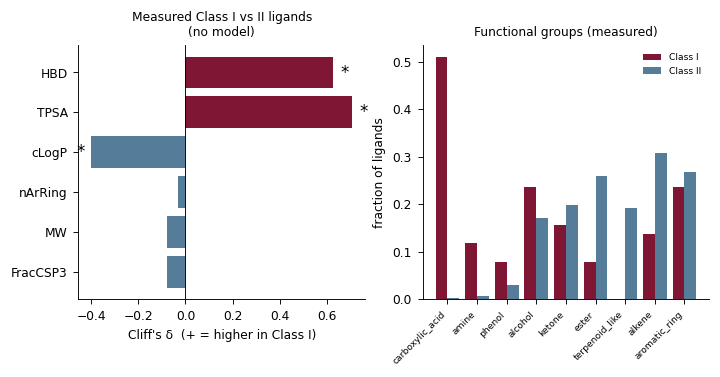

In [22]:
from scipy.stats import fisher_exact
fg_rows = []
for g in chem.SMARTS:
    a, b = int(feats.loc[xi, g].sum()), int(feats.loc[yi, g].sum())
    if a + b < 4:
        continue
    odds, p = fisher_exact([[a, len(xi)-a], [b, len(yi)-b]])
    fg_rows.append(dict(group=g, freq_I=a/len(xi), freq_II=b/len(yi), odds=odds, p=p))
fg_meas = pd.DataFrame(fg_rows)
fg_meas["q"] = chem._bh(fg_meas.p.values)
fg_meas.to_csv(OUT / "measured_classI_vs_classII_groups.csv", index=False)
print(fg_meas[fg_meas.q <= .05].round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0))
ax = axes[0]
dd = desc_meas.set_index("descriptor").loc[["HBD","TPSA","cLogP","nArRing","MW","FracCSP3"]]
y = np.arange(len(dd))
ax.barh(y, dd.cliffs_delta, color=[CLASS_I_COL if v > 0 else CLASS_II_COL
                                   for v in dd.cliffs_delta])
ax.set_yticks(y); ax.set_yticklabels(dd.index); ax.invert_yaxis()
ax.axvline(0, color="k", lw=.6)
ax.set_xlabel("Cliff's δ  (+ = higher in Class I)")
ax.set_title("Measured Class I vs II ligands\n(no model)", fontsize=8)
for yi_, (v, q) in enumerate(zip(dd.cliffs_delta, dd.q)):
    if q <= .05:
        ax.text(v + (.03 if v > 0 else -.03), yi_, "*", va="center",
                ha="left" if v > 0 else "right", fontsize=11)

ax = axes[1]
key_g = ["carboxylic_acid","terpenoid_like","amine","ester","alkene","ester"]
gg = fg_meas.set_index("group").reindex(
    ["carboxylic_acid","amine","phenol","alcohol","ketone","ester",
     "terpenoid_like","alkene","aromatic_ring"]).dropna()
x = np.arange(len(gg))
ax.bar(x - .2, gg.freq_I, .4, color=CLASS_I_COL, label="Class I")
ax.bar(x + .2, gg.freq_II, .4, color=CLASS_II_COL, label="Class II")
ax.set_xticks(x); ax.set_xticklabels(gg.index, rotation=45, ha="right", fontsize=6)
ax.set_ylabel("fraction of ligands"); ax.legend(fontsize=6, frameon=False)
ax.set_title("Functional groups (measured)", fontsize=8)
save(fig, "measured_classI_chemistry")

### 13.1 · Verdict — confirmed, and a discrepancy resolved

The model-predicted ancestral Class I signature is reproduced in purely measured binder
data, with nothing from the predictor:

| feature | ancestral prediction (node_2) | measured Class I ligands | agree? |
|---|---|---|---|
| carboxylic acid | gained, 23/26, Obs/Exp 8 | 51% vs 0% in Class II (OR 344, q<0.001) | ✔ |
| HBD | δ = +0.80 vs lost | δ = +0.63 vs Class II (q≈10⁻¹⁷) | ✔ |
| TPSA | δ = +0.75 vs lost | δ = +0.71 vs Class II (q≈10⁻¹⁵) | ✔ |
| terpenoid-like | 0 gained (depleted) | 0% vs 19% in Class II (q<0.001) | ✔ |
| amine | — | enriched in Class I (OR 22) | (Class II gained amines at node_6) |

**The one discrepancy, resolved.** In the ancestral edge test, cLogP did *not* separate
gained from lost (p = 0.39); in the measured class contrast, Class I ligands are clearly
lower cLogP (δ = −0.40, q≈10⁻⁶). These are not in conflict — they are different contrasts.
At node_2 the *lost* set (ketones, terpenoids) is itself mid-range cLogP, so gained-minus-lost
cancels on lipophilicity even though both differ from the panel. The Class I-vs-Class II
contrast does not cancel, because the Class II ligand space includes the high-cLogP
terpenoid region Class I never occupied. So the correct combined statement is:

> The Class I lineage is defined by acquisition of **hydrogen-bond-donating, polar
> headgroups** (carboxylic acids; higher HBD/TPSA) — a shift visible both in the ancestral
> reconstruction and in measured binders. Class I ligands are also **less lipophilic** than
> Class II ligands overall, but that difference reflects the *absence* of the hydrophobic
> terpenoid space that Class II separately expanded into, not a lipophilicity change on the
> Class I branch itself.

This is the model-independent ecological validation the project needed. The chemistry a
sequence-only model reconstructs for a 400-million-year-old ancestral node matches the
chemistry measured at the bench for its living descendants, and it matches the one solved
Class I OR structure (OR51E2 + propionate; Billesbølle et al. 2023). That closes the loop
between the ancestral analysis and ground truth without the predictor in the path.

## 14 · Ancestral ligand activation heatmap (node_1 / node_2 / node_3)

Before the enrichment tests, the visual that motivates them: the ligand repertoires of the
three founding ancestors at p ≥ 0.83, clustered by activation pattern. Rows are colour-coded
by class — **black = node_1 (Anc0, common ancestor)**, **red = node_2 (Anc1, Class I)**,
**blue = node_3 (Anc2, Class II)**. Columns are the 82 ligands in the union of the three,
ordered by their 3-bit (Class I, common, Class II) activation pattern in the fixed sequence
100 · 111 · 011 · 010 · 110 · 101 · 001, with the common ancestor placed in the middle row.
The strip beneath assigns each ligand to its pattern, matching the task-2 enrichment categories.

wrote Figures/ancestral_ligand_heatmap.svg


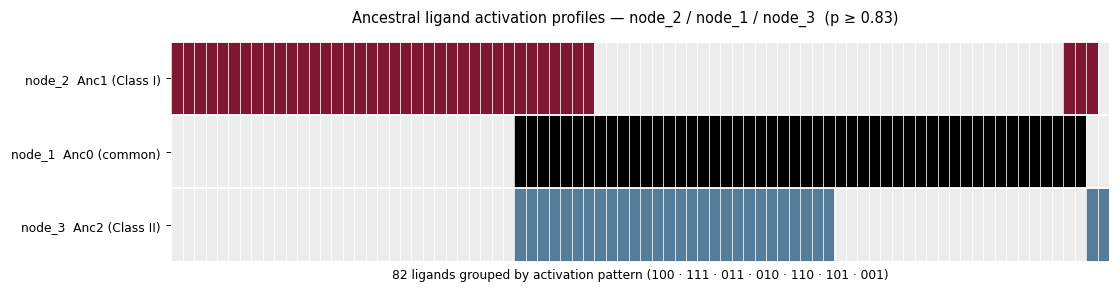

In [23]:
from matplotlib.patches import Patch

# row order: Class I (top), common ancestor (middle), Class II (bottom)
rows3 = ["node_2", "node_1", "node_3"]
ROWCOL = {"node_2": CLASS_I_COL, "node_1": "#000000", "node_3": CLASS_II_COL}
ROWLAB = {"node_2": "node_2  Anc1 (Class I)",
          "node_1": "node_1  Anc0 (common)",
          "node_3": "node_3  Anc2 (Class II)"}
sub = allb.loc[rows3]; sub = sub.loc[:, sub.sum(axis=0) > 0]
M = sub.values.astype(int)              # rows = (i=ClassI, j=common, k=ClassII)

# per-ligand pattern (i, j, k), grouped in the fixed block order
patt = [tuple(M[:, c]) for c in range(M.shape[1])]
ORDER = [(1,0,0), (1,1,1), (0,1,1), (0,1,0), (1,1,0), (1,0,1), (0,0,1)]
col_order = []
for p in ORDER:
    col_order += [c for c in range(len(patt)) if patt[c] == p]
col_order += [c for c in range(len(patt)) if patt[c] not in ORDER]  # safety net
Mo = M[:, col_order]
ncol = Mo.shape[1]

fig, axh = plt.subplots(figsize=(11, 2.6))
pale = np.array([0.93, 0.93, 0.93])
img = np.ones((3, ncol, 3))
for r, n in enumerate(rows3):
    c = mpl.colors.to_rgb(ROWCOL[n])
    for j in range(ncol):
        img[r, j] = c if Mo[r, j] else pale
axh.imshow(img, aspect="auto", interpolation="nearest", extent=[0, ncol, 3, 0])
# per-molecule gridlines: one thin white line between every column
for x in range(ncol + 1):
    axh.axvline(x, color="white", lw=0.5)
for y in range(4):
    axh.axhline(y, color="white", lw=1.2)
axh.set_yticks([0.5, 1.5, 2.5]); axh.set_yticklabels([ROWLAB[n] for n in rows3], fontsize=8)
axh.set_xticks([]); axh.set_xlim(0, ncol); axh.set_ylim(3, 0)
for s in axh.spines.values(): s.set_visible(False)
axh.set_xlabel(f"{ncol} ligands grouped by activation pattern "
               "(100 \u00b7 111 \u00b7 011 \u00b7 010 \u00b7 110 \u00b7 101 \u00b7 001)", fontsize=8)
fig.suptitle("Ancestral ligand activation profiles \u2014 node_2 / node_1 / node_3  (p \u2265 0.83)",
             fontsize=9.5, y=0.99)
save(fig, "ancestral_ligand_heatmap")

The fixed pattern order walks left-to-right through the evolutionary categories the enrichment then tests: a large **Class I private-gain** block (100, n≈30) carrying the acid character; the **shared core** (111, n=7); the single ligand gained by both descendants independently (101); the **lost-on-Class-I** block (011, n≈21, retained by Class II) carrying woody; the **lost-on-both** block (010, n≈20); and — the asymmetry that is itself a result — a Class II private-gain block (001) of just **one** ligand. Class II barely moved from the ancestor while Class I restructured its repertoire.

## 15 · Hypergeometric odor-tag enrichment of ancestral repertoires

Three enrichment analyses at the calibrated threshold (p ≥ 0.83), all using the
**hypergeometric test** with the **union of the compared nodes' ligands** as the universe.

**Methods (paper text).** For each receptor group we tested whether individual odor
descriptors were over-represented among its ligand set using the hypergeometric
distribution (equivalently, a one-tailed Fisher exact test). Given a universe of *N*
tagged ligands — the union of ligands bound by the compared ancestral nodes at p ≥ 0.83 —
of which *K* carry a given tag, a node binding *n* tagged ligands of which *k* carry the
tag gives an enrichment probability P(X ≥ k) = Σ_{i=k}^{min(n,K)} C(K,i)C(N−K,n−i)/C(N,n).
Fold enrichment is (k/n)/(K/N). P-values were computed for every tag with ≥ 3 ligands in
the group (≥ 2 for the smaller pattern categories) and corrected across tags within each
analysis by Benjamini–Hochberg; tags with q ≤ 0.05 and fold > 1 were called enriched.

Note this is the parametric analogue of the permutation enrichment used elsewhere in the
manuscript; it treats tags as independent Bernoulli draws and so ignores tag co-occurrence
structure, trading a small amount of realism for a closed-form p-value. Results agree with
the permutation version on these sets.

In [24]:
# import tagenrich as te  (inlined in setup)
tags = te.build_tag_table(odors, m2or)

def enrich_barplot(df, title, fname, qcap=0.05, max_tags=14):
    d = df[(df.q <= qcap) & (df.fold > 1)].sort_values("fold", ascending=True)
    if len(d) == 0:
        print(f"[{title}] no enriched tags"); return
    d = d.tail(max_tags)
    fig, ax = plt.subplots(figsize=(4.2, .32*len(d) + .8))
    y = np.arange(len(d))
    bars = ax.barh(y, d.fold, color=CLASS_I_COL, alpha=.85, edgecolor="none")
    ax.axvline(1, ls="--", lw=.6, color="#888")
    ax.set_yticks(y); ax.set_yticklabels(d.tag, fontsize=7)
    ax.set_xlabel("fold enrichment"); ax.set_title(title, fontsize=8)
    xmax = d.fold.max()
    for yi, (f, q) in enumerate(zip(d.fold, d.q)):
        ax.text(f + xmax*0.02, yi, f"q={q:.3f}", va="center", fontsize=6, color="#333")
    ax.set_xlim(0, xmax*1.28)
    save(fig, fname)
    return d

### 14.1 · Task 1 — the three founding ancestors (node_1, node_2, node_3)

Universe = union of the three nodes' ligands (N = 53 tagged). The full-754-panel version
is computed as a supplement; it inflates significance because it imports the whole assay
panel's composition, which is why the union is primary.

wrote Figures/tagenrich_task1_node_1.svg


wrote Figures/tagenrich_task1_node_2.svg
wrote Figures/tagenrich_task1_node_3.svg
task1 (union) enriched q<=0.05:
 group    tag  k  n  fold     q
node_1  sweet 26 36 1.276 0.028
node_2  fatty 10 21 2.294 0.002
node_2   waxy 10 21 1.941 0.010
node_2 cheesy  6 21 2.524 0.010
node_3  woody 10 21 2.103 0.013


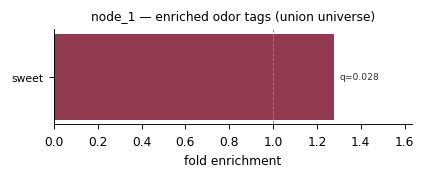

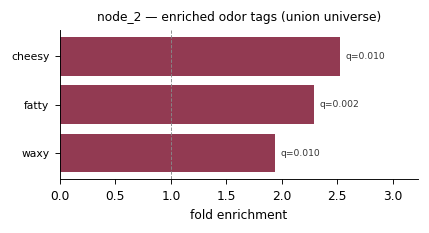

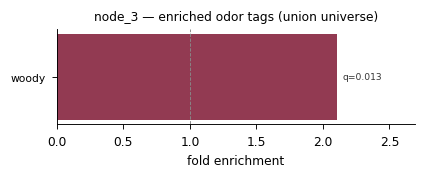

In [25]:
uni3 = list(allb.columns[allb.loc[["node_1","node_2","node_3"]].any(axis=0)])
panel = list(allb.columns)
task1 = []
for n in ["node_1","node_2","node_3"]:
    r = te.hyper_enrich(te.node_ligands(allb, n), uni3, tags, label=n)
    task1.append(r)
    enrich_barplot(r, f"{n} — enriched odor tags (union universe)",
                   f"tagenrich_task1_{n}")
task1 = pd.concat(task1, ignore_index=True)
task1.to_csv(OUT / "tagenrich_task1_union.csv", index=False)

sup = pd.concat([te.hyper_enrich(te.node_ligands(allb, n), panel, tags, label=n)
                 for n in ["node_1","node_2","node_3"]], ignore_index=True)
sup.to_csv(OUT / "tagenrich_task1_fullpanel_supplement.csv", index=False)
print("task1 (union) enriched q<=0.05:")
print(task1[task1.q <= .05][["group","tag","k","n","fold","q"]].round(3).to_string(index=False))

### 14.5 · Task 1 — combined figure (both universes, all three ancestors)

One panel per node; within each, two bars per tag — union universe (dark red) vs full
754-panel (gold) — with the q-value beside every bar. A tag shows if significant in
*either* universe. node_2's acid signature (fatty/cheesy/waxy/sour) is significant under
**both** universes, the robustness check; node_1 and node_3 pick up their extra hydrophobic/
sweet tags only against the full panel, because within the shared ancestral pool those tags
are split between the two hydrophobic-leaning nodes and cancel.

wrote Figures/tagenrich_task1_combined.svg


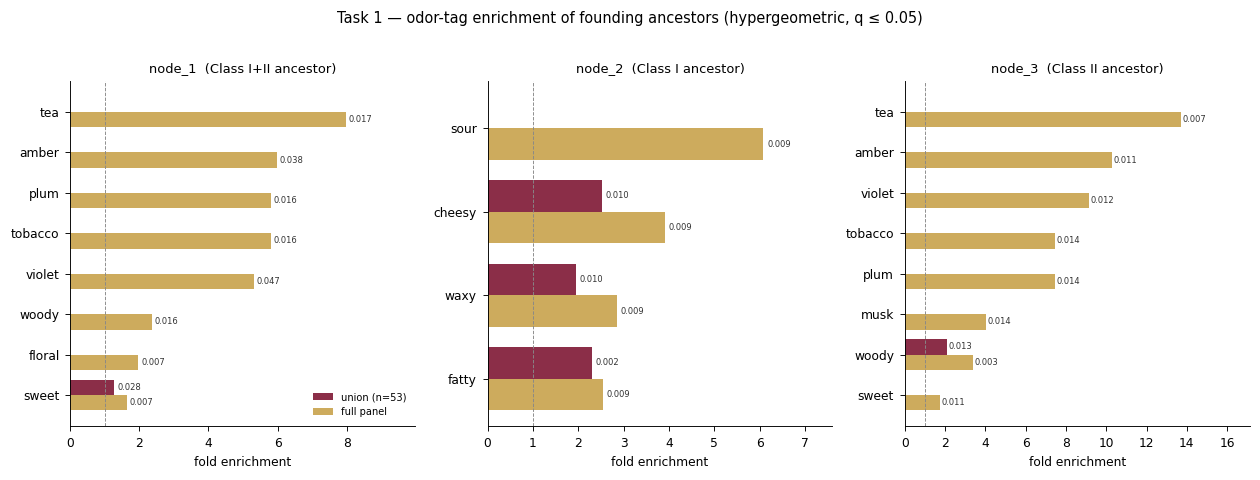

In [26]:
u = pd.read_csv(OUT / "tagenrich_task1_union.csv")
p = pd.read_csv(OUT / "tagenrich_task1_fullpanel_supplement.csv")
u["universe"] = "union (n=53)"; p["universe"] = "full panel"
both = pd.concat([u, p], ignore_index=True)
UNION_COL, PANEL_COL = "#7f1734", "#c8a24b"
titles = {"node_1": "node_1  (Class I+II ancestor)",
          "node_2": "node_2  (Class I ancestor)",
          "node_3": "node_3  (Class II ancestor)"}

fig, axes = plt.subplots(1, 3, figsize=(11.5, 4.2))
for ax, n in zip(axes, ["node_1", "node_2", "node_3"]):
    d = both[(both.group == n) & (both.q <= 0.05) & (both.fold > 1)]
    order = d.groupby("tag").fold.max().sort_values().index.tolist()
    y = np.arange(len(order)); h = 0.38
    for uni, col, off in [("union (n=53)", UNION_COL, +h/2),
                          ("full panel", PANEL_COL, -h/2)]:
        sub = d[d.universe == uni].set_index("tag").reindex(order)
        ax.barh(y + off, sub.fold.fillna(0).values, height=h, color=col,
                alpha=.9, label=uni, edgecolor="none")
        for yi, (f, q) in enumerate(zip(sub.fold.values, sub.q.values)):
            if not np.isnan(f):
                ax.text(f + 0.08, y[yi] + off, f"{q:.3f}", va="center",
                        fontsize=5.5, color="#333")
    ax.axvline(1, ls="--", lw=.6, color="#888")
    ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8)
    ax.set_xlabel("fold enrichment"); ax.set_title(titles[n], fontsize=8.5)
    ax.set_xlim(0, max(3.2, d.fold.max()*1.25))
    if n == "node_1":
        ax.legend(fontsize=6.5, frameon=False, loc="lower right")
fig.suptitle("Task 1 — odor-tag enrichment of founding ancestors "
             "(hypergeometric, q ≤ 0.05)", fontsize=9.5, y=1.02)
fig.tight_layout()
save(fig, "tagenrich_task1_combined")

### 14.2 · Task 2 — the six evolutionary pattern categories

Categories are mutually exclusive and defined relative to **node_1 as the ancestor**:
`shared_all` (in all three), `gain_a_only`/`gain_b_only` (private gains on the node_2 /
node_3 branch), `loss_a_only`/`loss_b_only` (lost on one branch only), `lost_both` (lost on
both). Universe is the same node_1/2/3 union, so this is directly comparable to task 1.

Two categories — `gain_b_only` (1 ligand) and `loss_b_only` (2 ligands) — are too small to
test. That emptiness is the Class II result: almost nothing was privately gained or lost on
the node_3 branch relative to the ancestor.

category sizes: {'shared_all': 7, 'gain_a_only': 30, 'gain_b_only': 1, 'loss_a_only': 21, 'loss_b_only': 2, 'lost_both': 20}
[shared_all  (n=7)] no enriched tags
wrote Figures/tagenrich_task2_gain_a_only.svg
  gain_b_only: 1 ligands — not testable
wrote Figures/tagenrich_task2_loss_a_only.svg
  loss_b_only: 2 ligands — not testable
[lost_both  (n=20)] no enriched tags

      group    tag  k  n  fold     q
gain_a_only  fatty 10 17 2.834 0.000
gain_a_only   waxy 10 17 2.398 0.002
gain_a_only cheesy  6 17 3.118 0.004
gain_a_only   sour  4 17 3.118 0.043
loss_a_only  woody  9 18 2.208 0.036


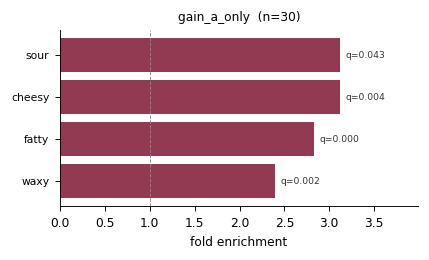

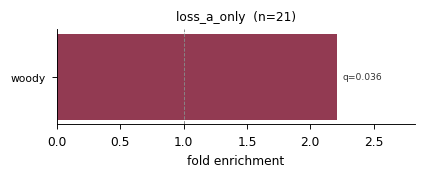

In [27]:
cats = te.pattern_sets(allb, ref="node_1", a="node_2", b="node_3")
print("category sizes:", {k: len(v) for k, v in cats.items()})
task2 = []
for cat, ids in cats.items():
    if len(ids) < 3:
        print(f"  {cat}: {len(ids)} ligands — not testable"); continue
    r = te.hyper_enrich(ids, uni3, tags, min_count=2, label=cat)
    task2.append(r)
    enrich_barplot(r, f"{cat}  (n={len(ids)})", f"tagenrich_task2_{cat}", qcap=0.10)
task2 = pd.concat(task2, ignore_index=True) if task2 else pd.DataFrame()
task2.to_csv(OUT / "tagenrich_task2_patterns.csv", index=False)
print()
print(task2[task2.q <= .10][["group","tag","k","n","fold","q"]].round(3).to_string(index=False))

### 14.3 · Task 3 — the ten key nodes down the tree

Universe = union of all ten nodes' ligands (N = 78 tagged). This traces how tag enrichment
shifts along the Class II backbone (node_6 → 12 → 21 → 32 → 44) and contrasts it with the
Class I nodes (node_2, node_4, node_5).

wrote Figures/tagenrich_task3_node_1.svg
wrote Figures/tagenrich_task3_node_2.svg
wrote Figures/tagenrich_task3_node_3.svg


wrote Figures/tagenrich_task3_node_4.svg
wrote Figures/tagenrich_task3_node_5.svg
wrote Figures/tagenrich_task3_node_6.svg
wrote Figures/tagenrich_task3_node_12.svg


wrote Figures/tagenrich_task3_node_21.svg
wrote Figures/tagenrich_task3_node_32.svg
wrote Figures/tagenrich_task3_node_44.svg


wrote Figures/tagenrich_task3_grid.svg
  group      tag  fold     q
 node_1    sweet 1.407 0.014
 node_1    woody 1.810 0.020
 node_1    spicy 2.111 0.033
 node_2    fatty 2.262 0.014
 node_3    woody 2.585 0.004
 node_4    fatty 2.205 0.001
 node_4   cheesy 2.443 0.002
 node_4     waxy 1.900 0.002
 node_4     sour 2.413 0.004
 node_4 odorless 2.714 0.015
 node_5   citrus 2.621 0.041
 node_5     waxy 1.703 0.046
 node_6    sweet 1.392 0.034
node_12    sweet 1.705 0.011
node_12    amber 4.750 0.044
node_21    amber 5.846 0.041
node_21    sweet 1.649 0.042
node_32    amber 5.846 0.037
node_32    sweet 1.649 0.037
node_44    sweet 1.670 0.018
node_44    amber 5.429 0.018


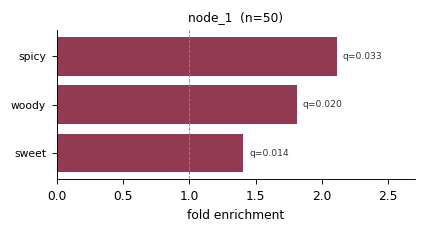

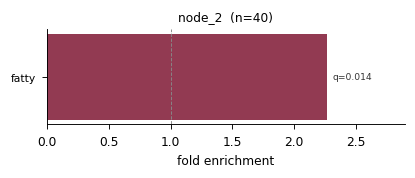

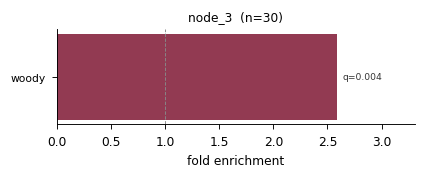

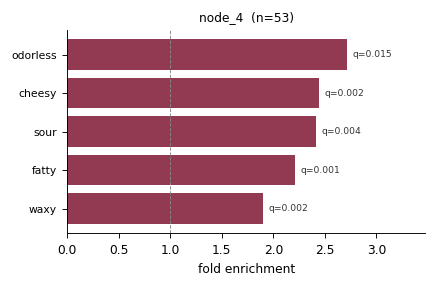

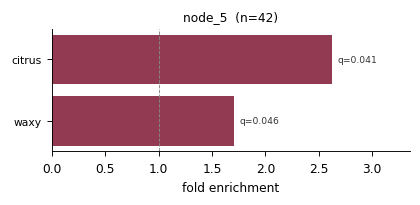

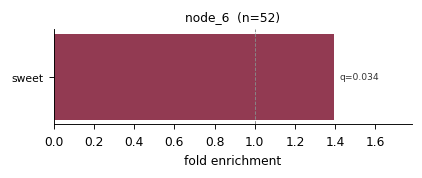

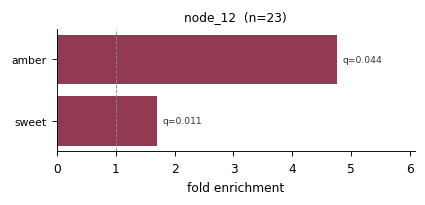

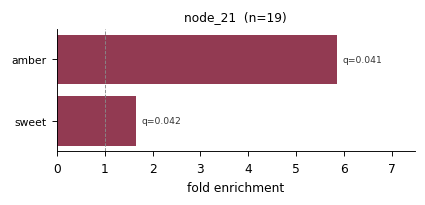

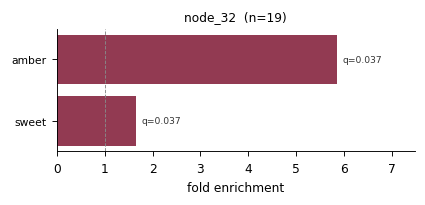

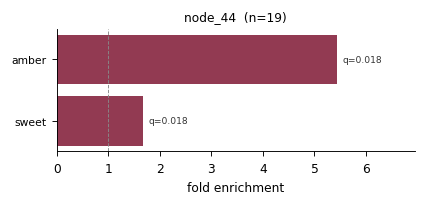

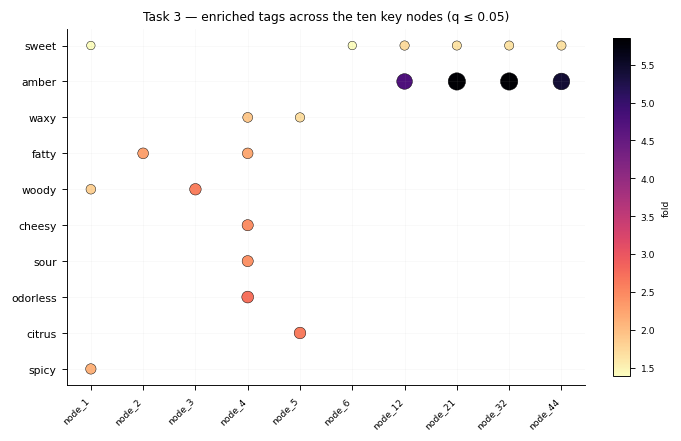

In [28]:
KEY10 = [f"node_{q}" for q in (1,2,3,4,5,6,12,21,32,44)]
uniK = list(allb.columns[allb.loc[KEY10].any(axis=0)])
task3 = []
for n in KEY10:
    r = te.hyper_enrich(te.node_ligands(allb, n), uniK, tags, label=n)
    if len(r):
        task3.append(r)
        enrich_barplot(r, f"{n}  (n={int(allb.loc[n].sum())})", f"tagenrich_task3_{n}")
task3 = pd.concat(task3, ignore_index=True)
task3.to_csv(OUT / "tagenrich_task3_keynodes.csv", index=False)

# compact overview: enriched tag x node grid
sig = task3[task3.q <= .05]
grid = sig.pivot_table(index="tag", columns="group", values="fold")
grid = grid.reindex(columns=[c for c in KEY10 if c in grid.columns])
grid = grid.loc[grid.notna().sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(6.6, .3*len(grid)+1.2))
Xg, Yg = np.meshgrid(np.arange(grid.shape[1]), np.arange(grid.shape[0]))
v = grid.values
sc = ax.scatter(Xg[~np.isnan(v)], Yg[~np.isnan(v)], s=22*v[~np.isnan(v)],
                c=v[~np.isnan(v)], cmap="magma_r", edgecolor="k", linewidth=.3)
ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns, rotation=45,
                                                        ha="right", fontsize=6)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index, fontsize=7)
ax.invert_yaxis(); ax.grid(alpha=.12, lw=.4)
cb = fig.colorbar(sc, ax=ax, fraction=.03); cb.set_label("fold", size=6); cb.ax.tick_params(labelsize=6)
ax.set_title("Task 3 — enriched tags across the ten key nodes (q ≤ 0.05)", fontsize=8)
save(fig, "tagenrich_task3_grid")
print(sig[["group","tag","fold","q"]].round(3).to_string(index=False))

### 14.4 · Reading the three analyses together

The three tasks tell one consistent story, and it matches the chemistry from §10 and §13:

- **Task 1.** The Class I ancestor (node_2) is enriched for **fatty, waxy, cheesy** — the
  perceptual signature of short-chain carboxylic acids. The Class II ancestor (node_3) is
  enriched for **woody**. Their parent node_1 sits between them (sweet/woody/spicy),
  consistent with a mixed ancestral repertoire that the two branches then specialised.

- **Task 2.** The enrichment lives entirely in `gain_a_only` — the ligands privately
  gained on the Class I branch — which carries **fatty, waxy, cheesy, sour** at 2.4–3.1×.
  `loss_a_only` is **woody**. The Class II gain/loss categories are too small to test at
  all: the node_3 branch privately gained 1 ligand and lost 2. The acid signature is thus
  specifically a *gain* event on the Class I branch, not a property of the shared ancestor.

- **Task 3.** Down the Class II backbone (node_6 → 12 → 21 → 32 → 44) the enriched tags
  freeze on **sweet + amber** (amber at ~5–6× and stable across all four deeper nodes),
  mirroring the near-static repertoire found in §3/§6. The Class I nodes (node_4 especially)
  carry the fatty/cheesy/sour/waxy acid block. Two lineages, two stable perceptual
  identities, established at the base and largely retained.

Together with the model-independent measured-binder confirmation in §13, the odor-tag layer
and the chemistry layer now agree: **Class I = acid / H-bond-donor / fatty-cheesy-sour;
Class II = terpenoid / hydrophobic / sweet-amber-woody**, a split that predates the
lineage radiations and is reconstructed here from sequence alone.